In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

In [2]:
# -----------------------------
# load + average folds
# -----------------------------

def load_folds(base_dir, n_folds=5):
    folds = []
    for f in range(n_folds):
        path = os.path.join(base_dir, f"fold_{f}", "ig_results.pt")
        folds.append(torch.load(path, map_location="cpu"))
    return folds


def average_folds(folds, scalars, K=9):
    out = {}

    for s in scalars:
        chan = sum(f["channel"][s] for f in folds) / len(folds)
        spat = sum(f["spatial"][s] for f in folds) / len(folds)
        temp = sum(f["temporal"][s] for f in folds) / len(folds)

        out[s] = {"channel": chan, "spatial": spat, "temporal": temp}

    return out



In [3]:
scalars = ["mu", "sigma", "gamma", "tau", "mean", "median", "p_gt_2", "p_lt_-2"]
base_dir = "results/ig/cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL"

folds = load_folds(base_dir)
avg = average_folds(folds, scalars)

In [4]:
#channel avgs: order var1 (925), var2(850), etc.. levels are [925 850 700 500 300]. variable order is: 10m_u_component_of_wind, v, 2m dp, 2mt, |(begin vertical)| geopotential, Q, u, v, w

In [5]:
avg['mean']['channel'][7].mean() # why is this one so much bigger??

tensor(2709963.2500)

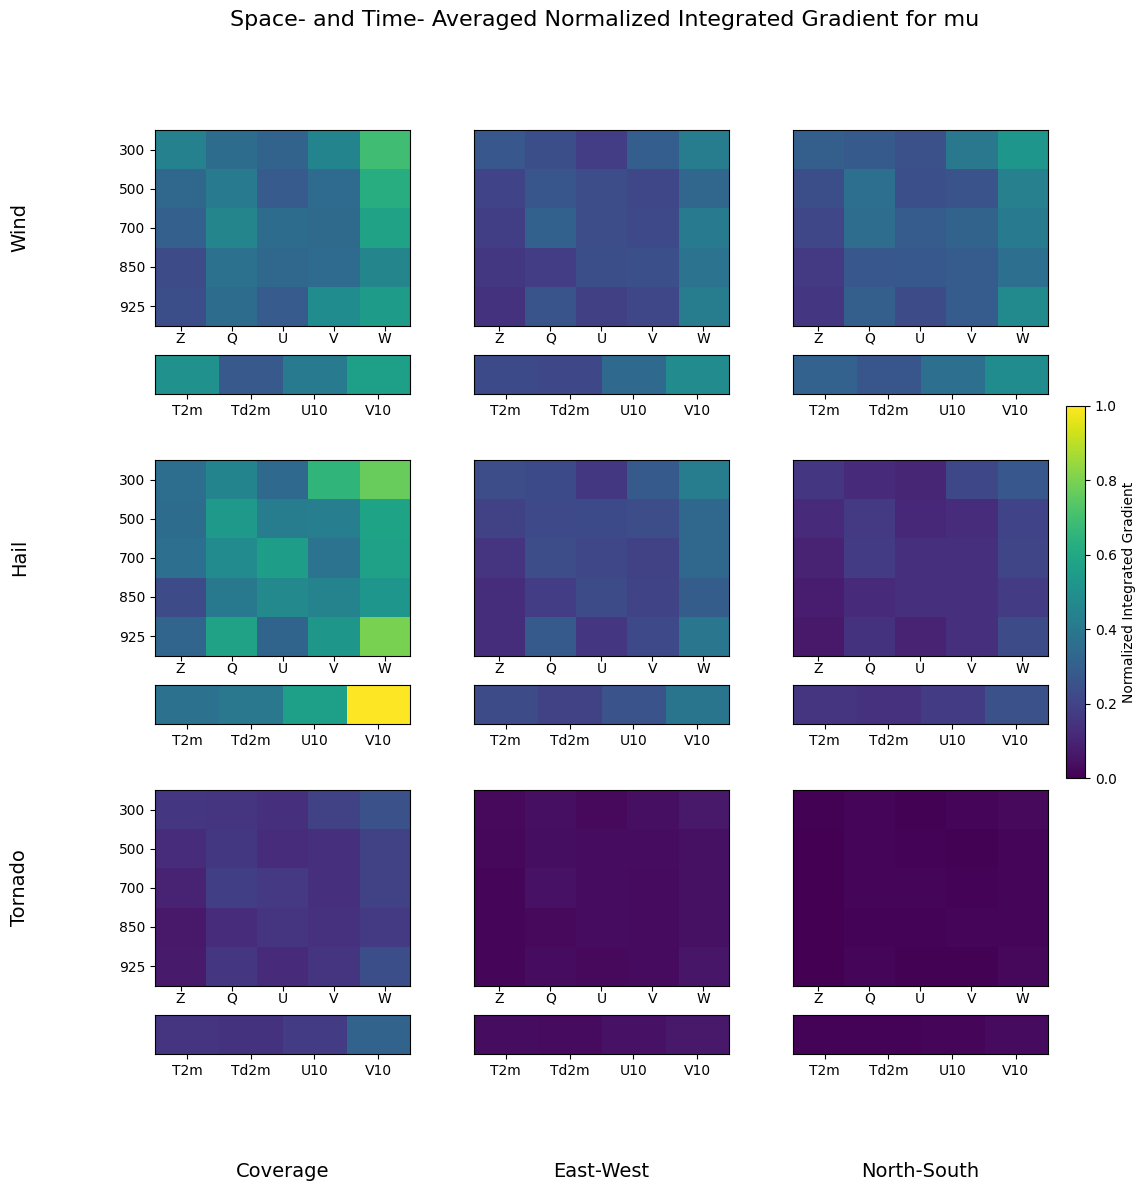

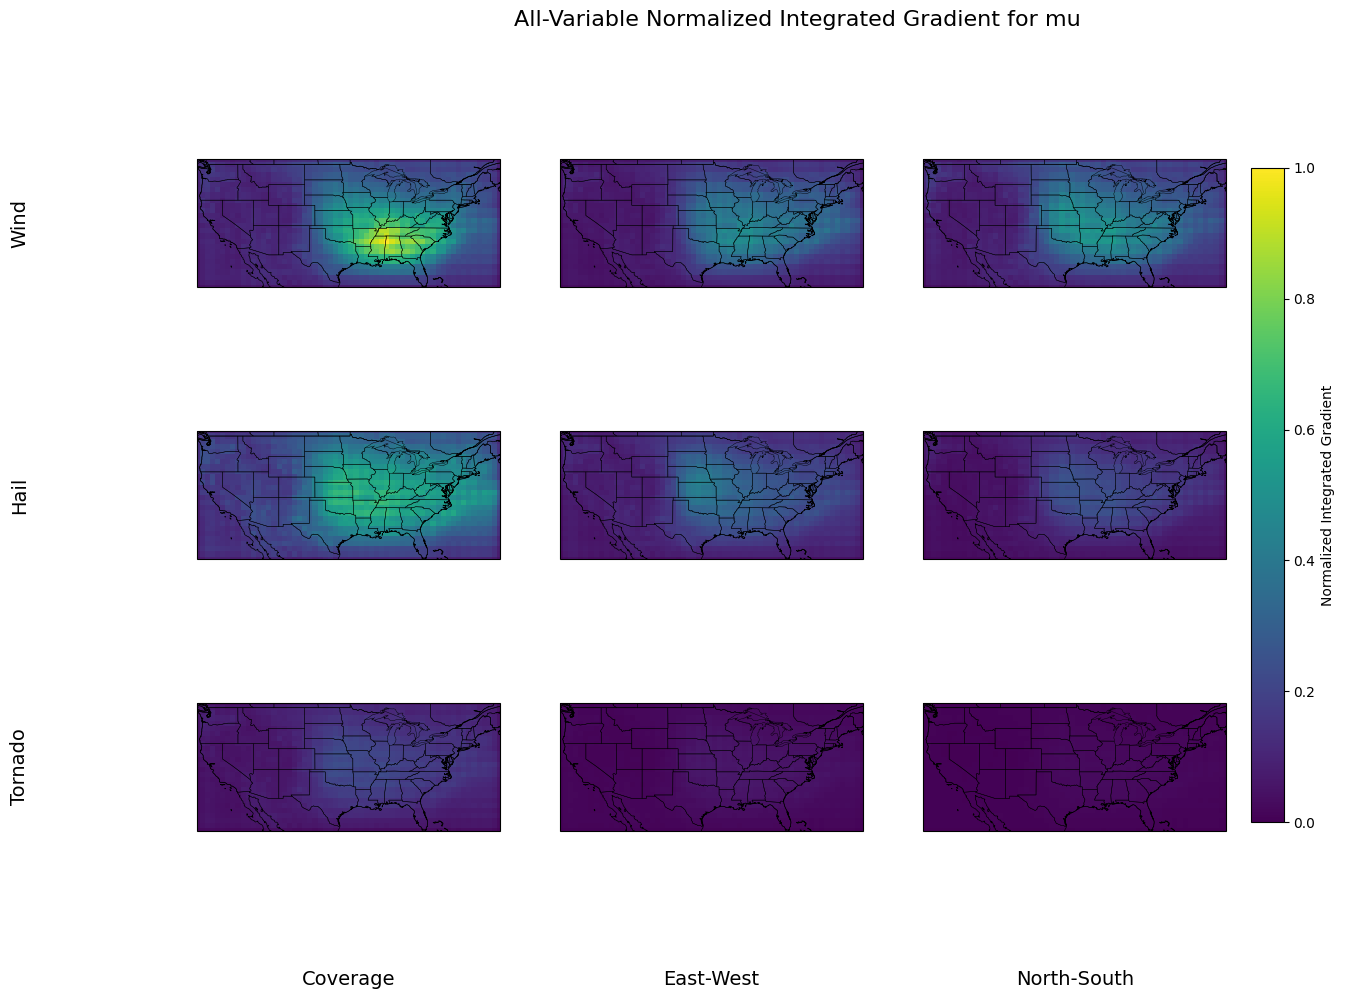

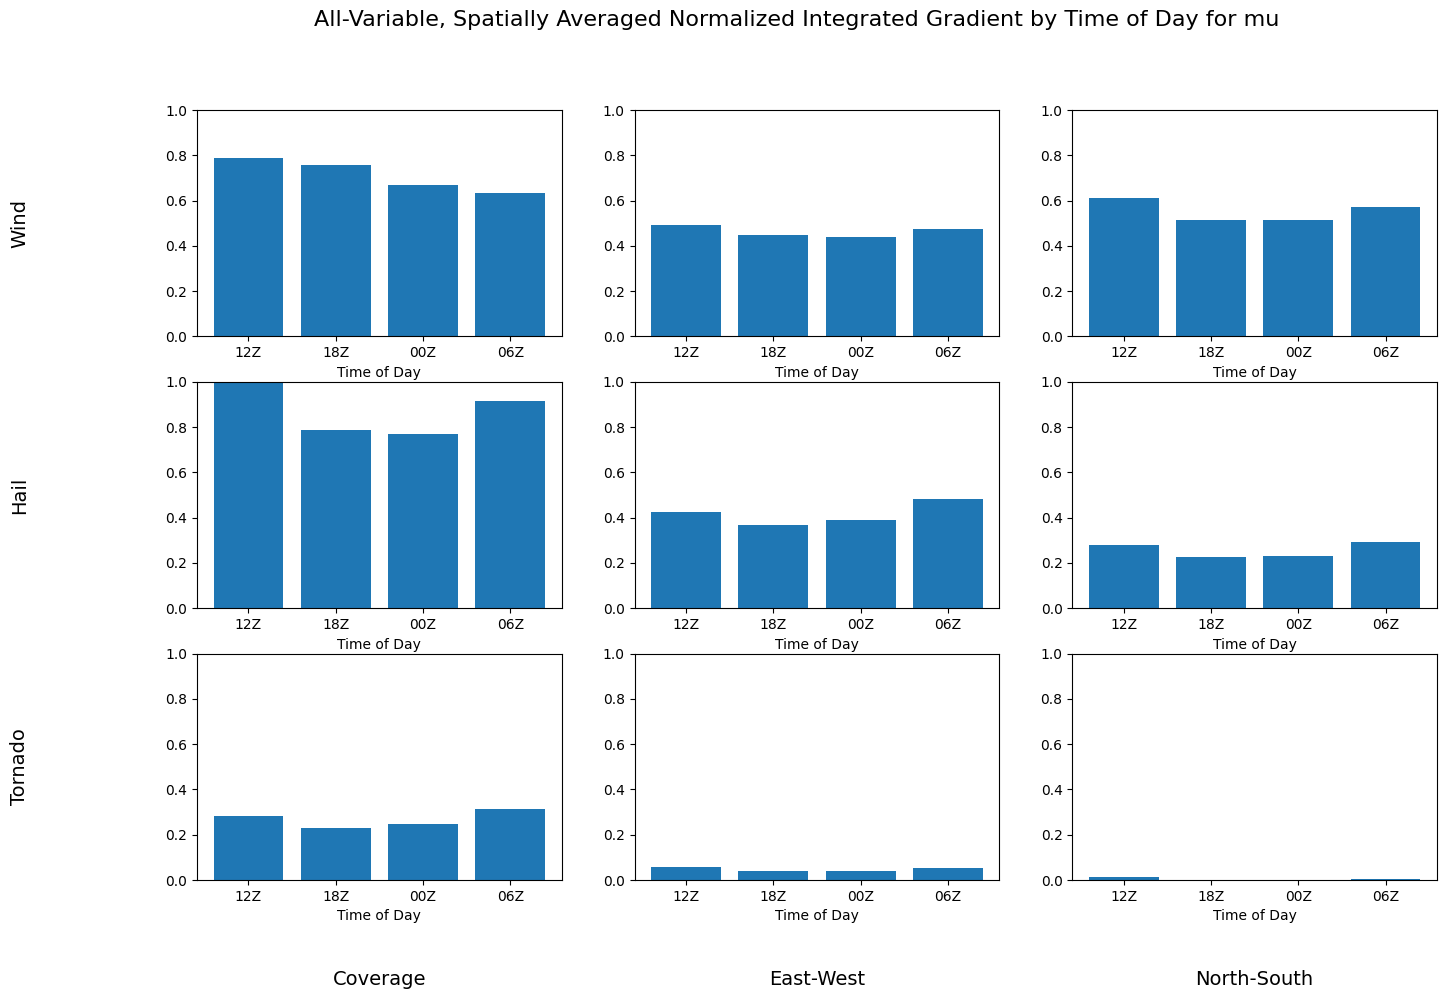

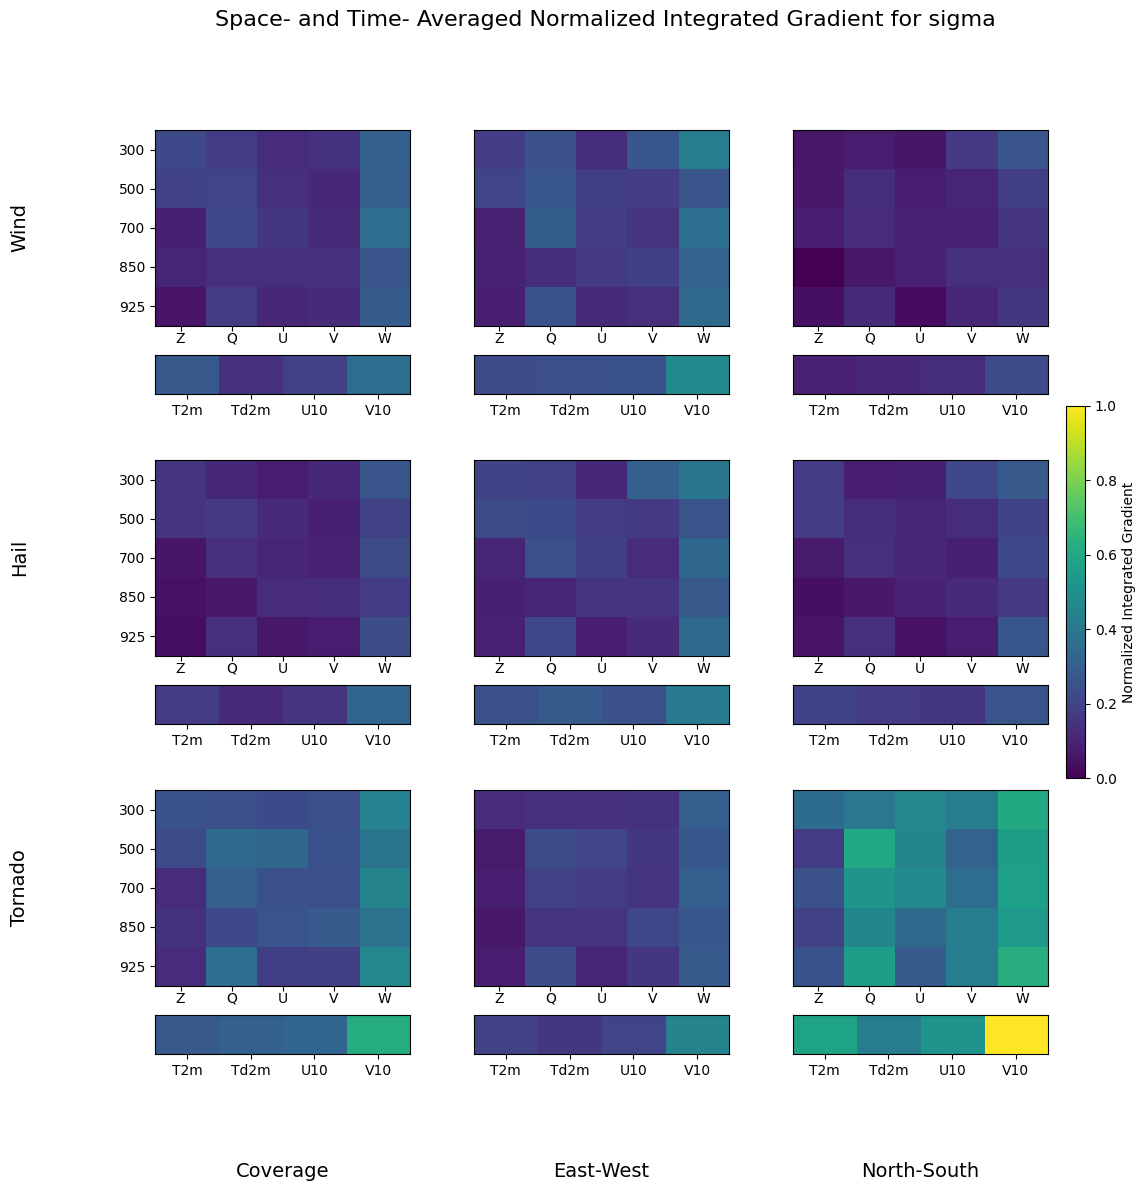

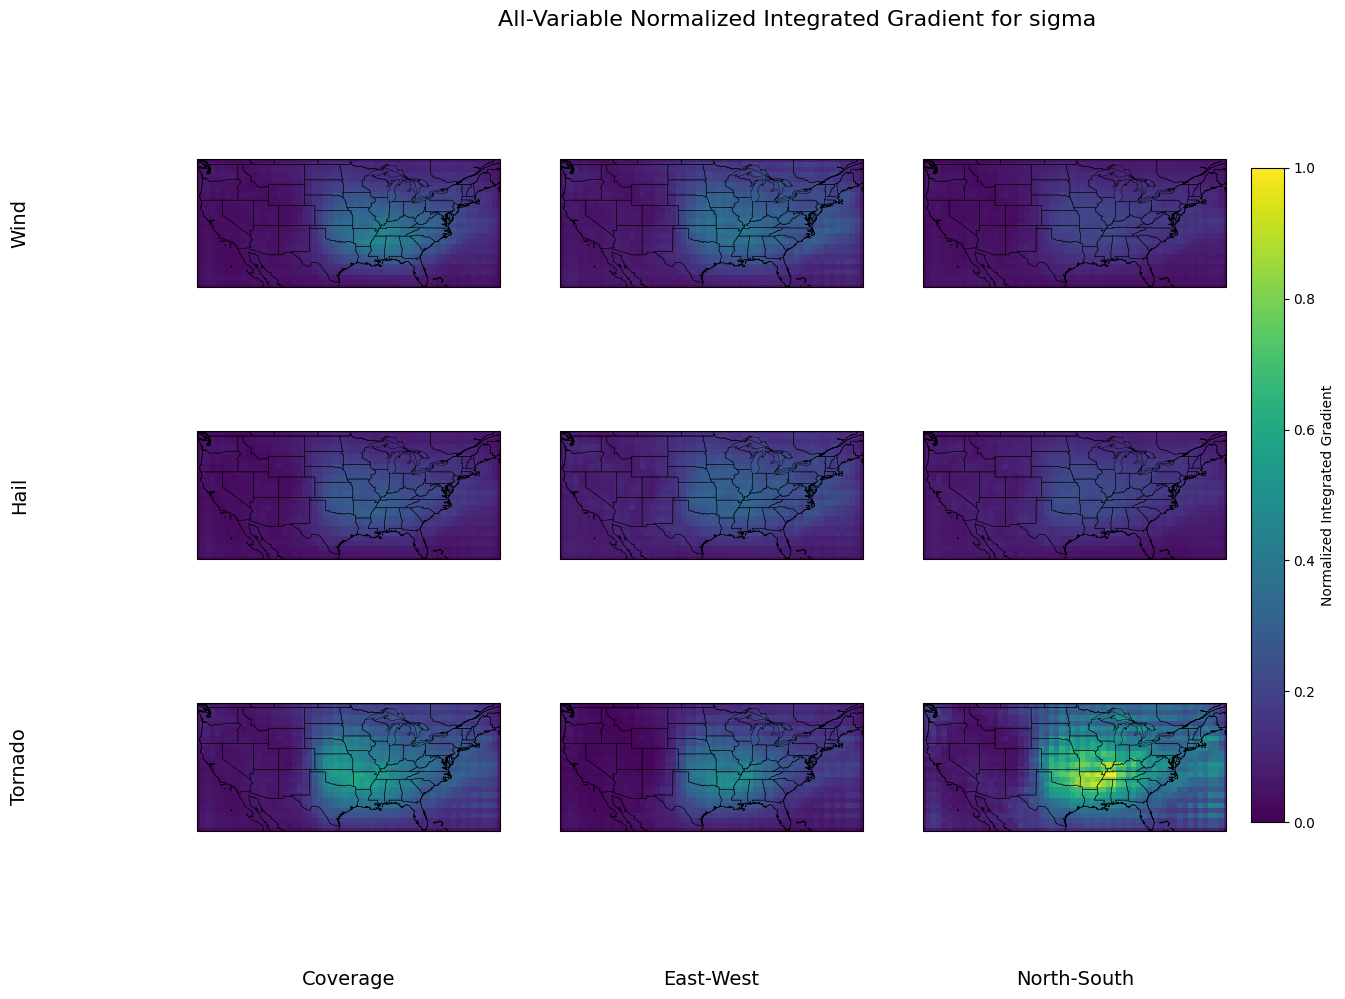

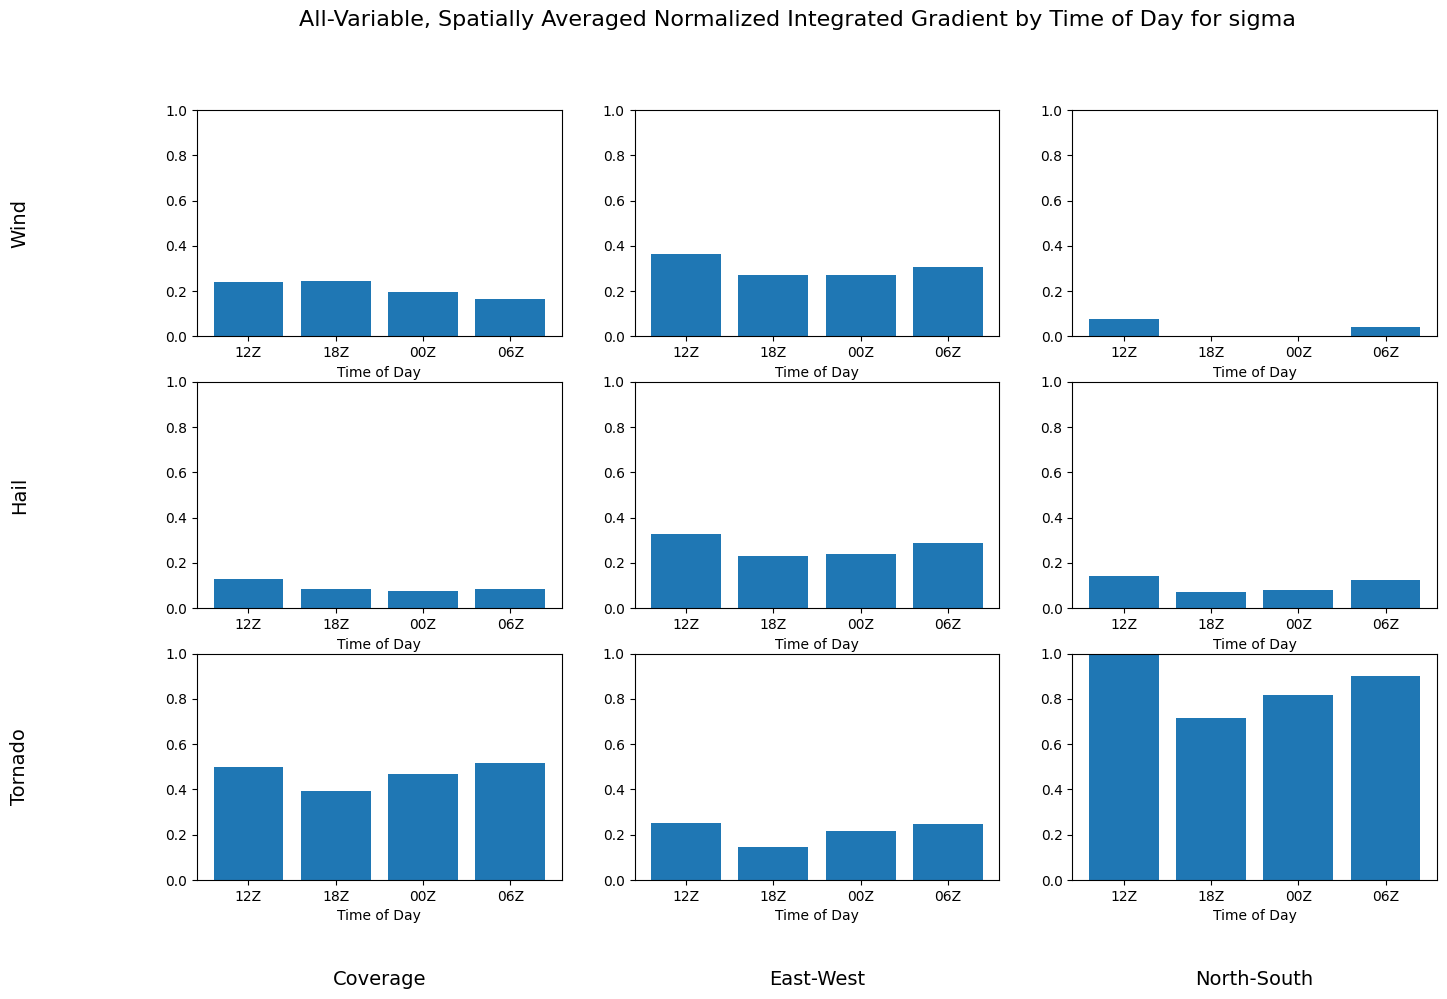

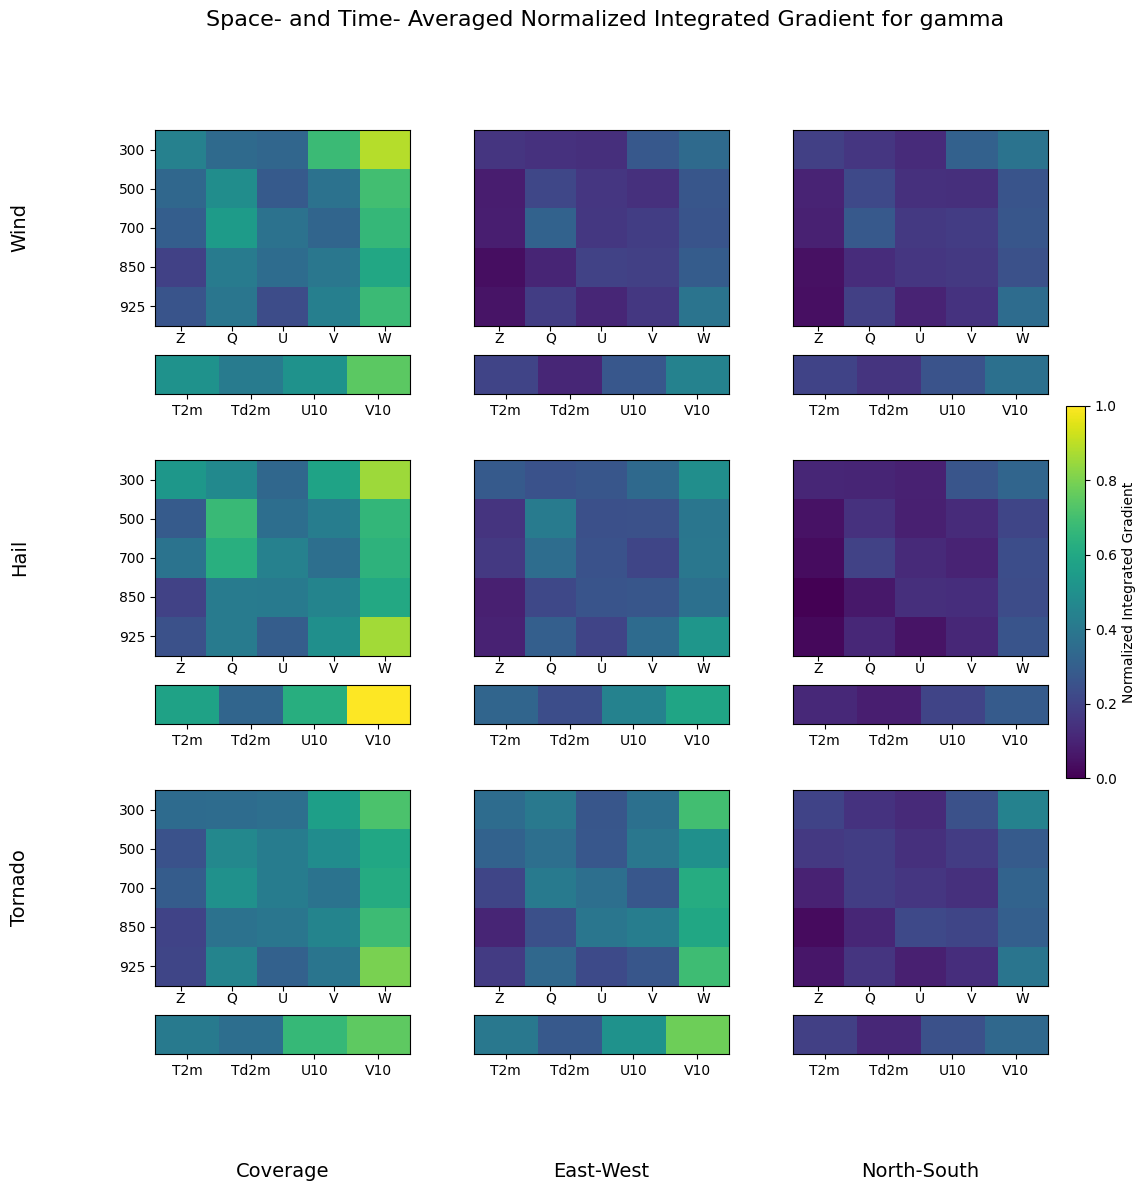

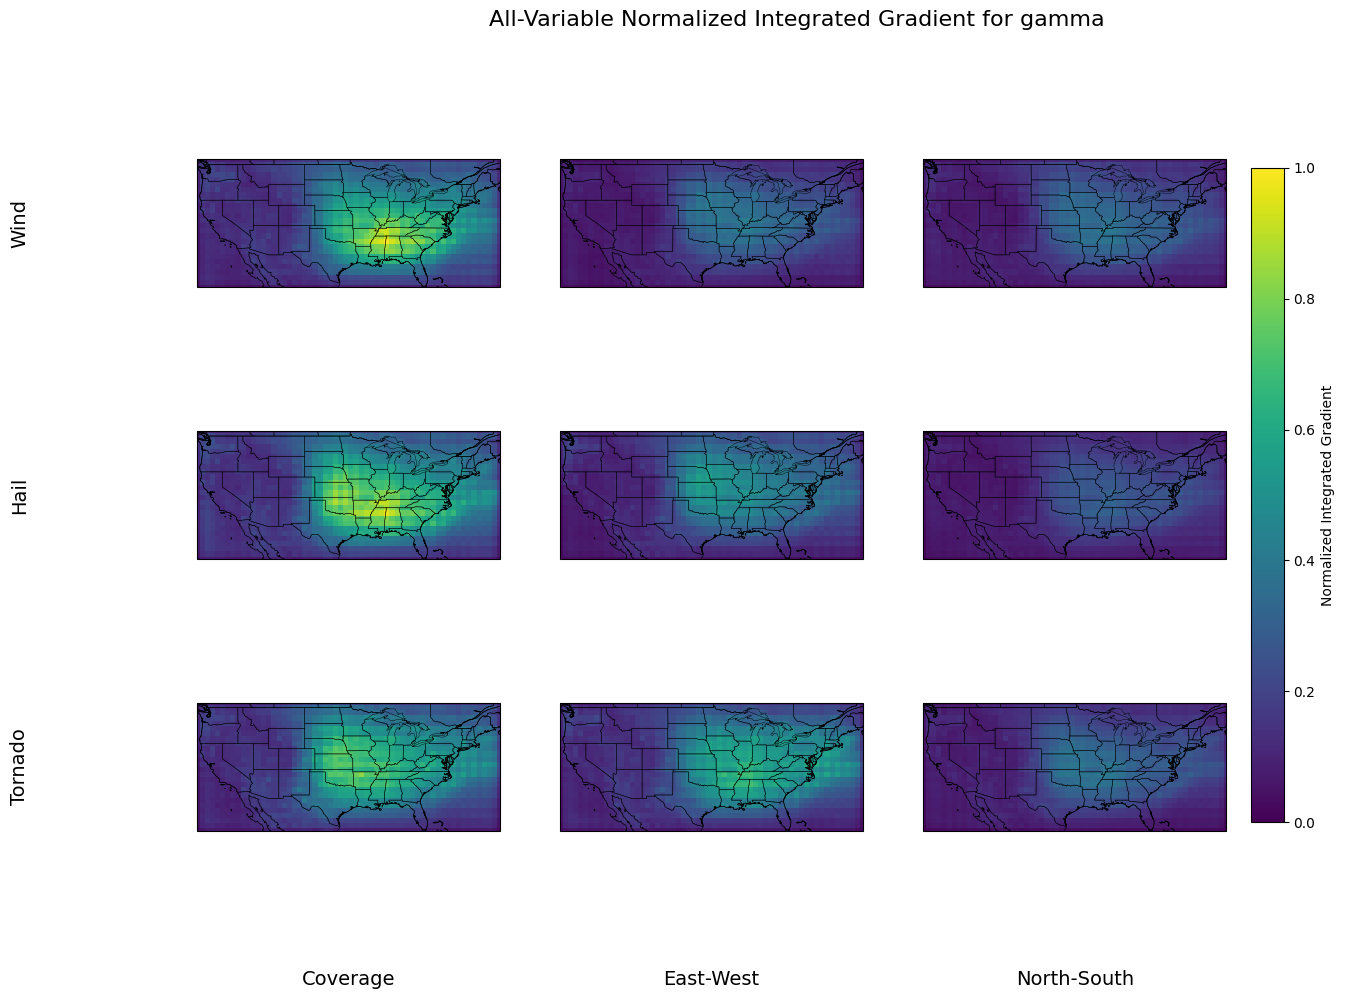

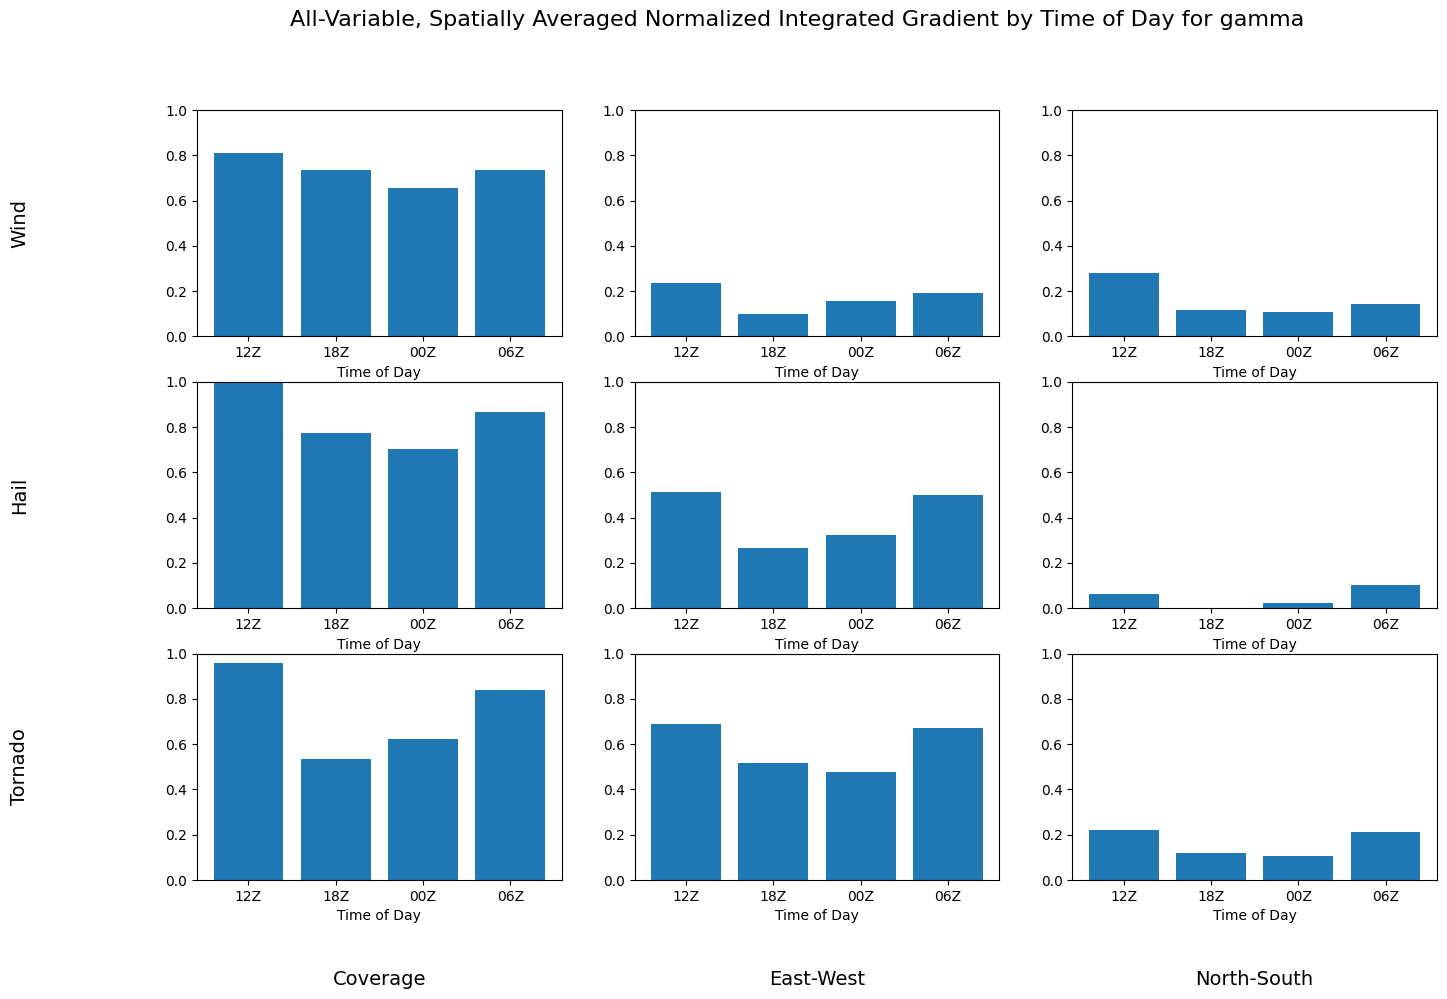

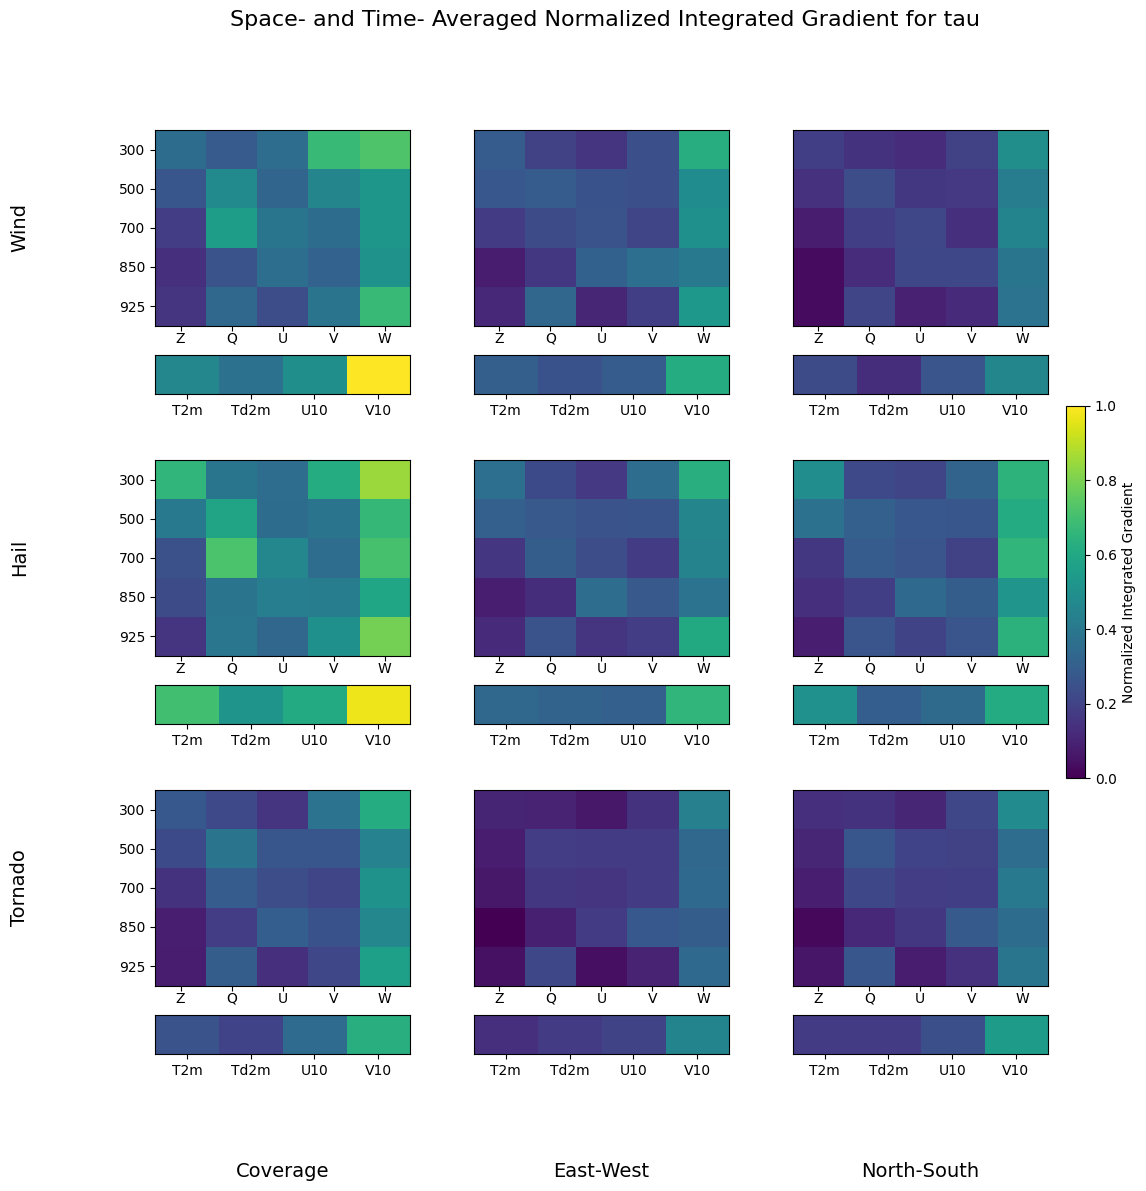

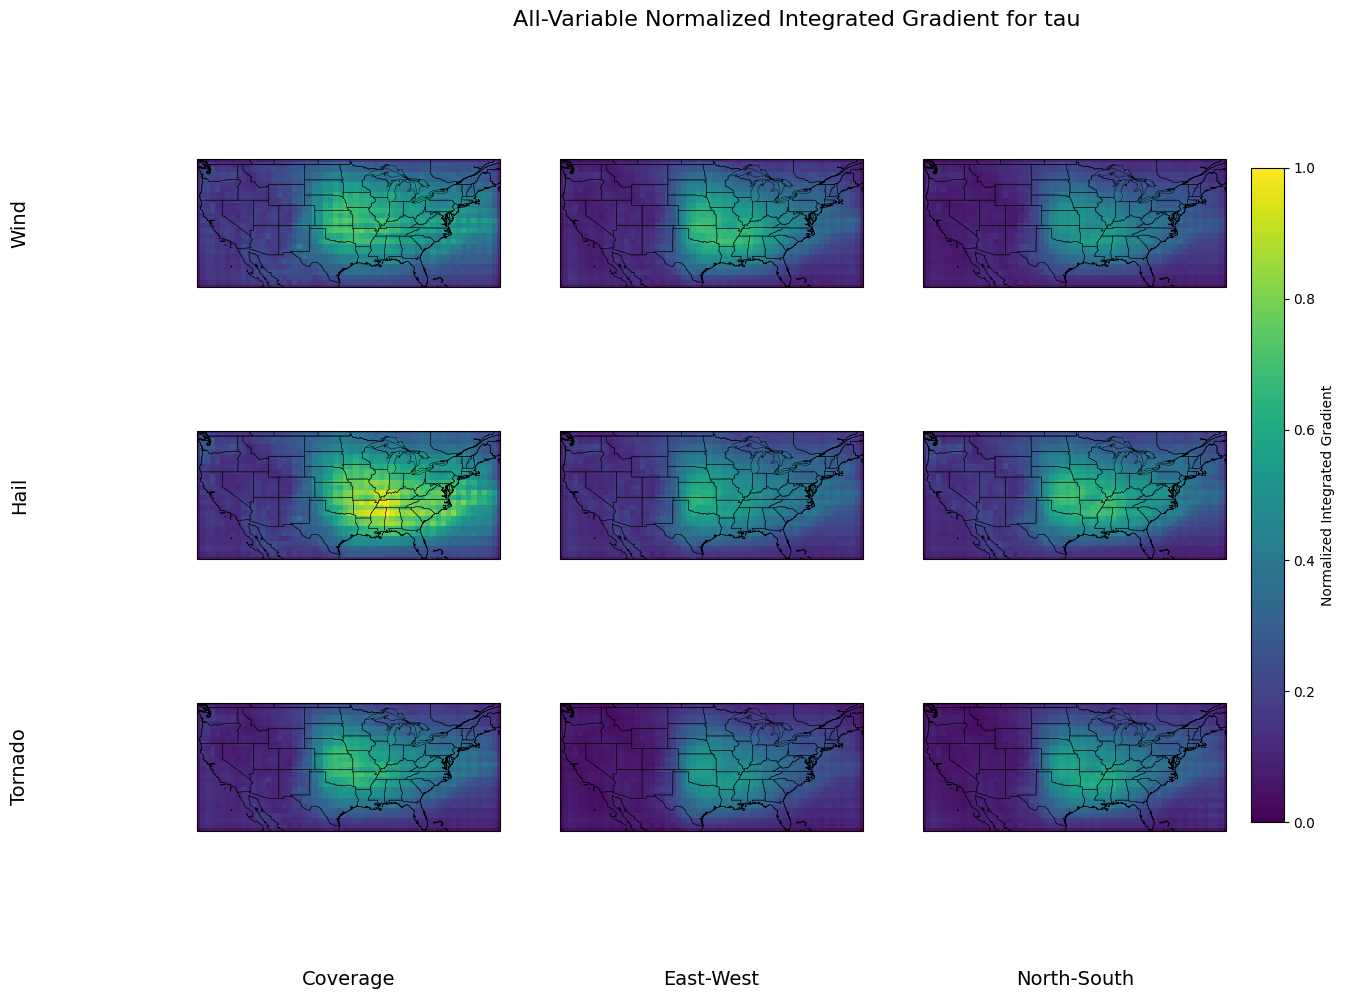

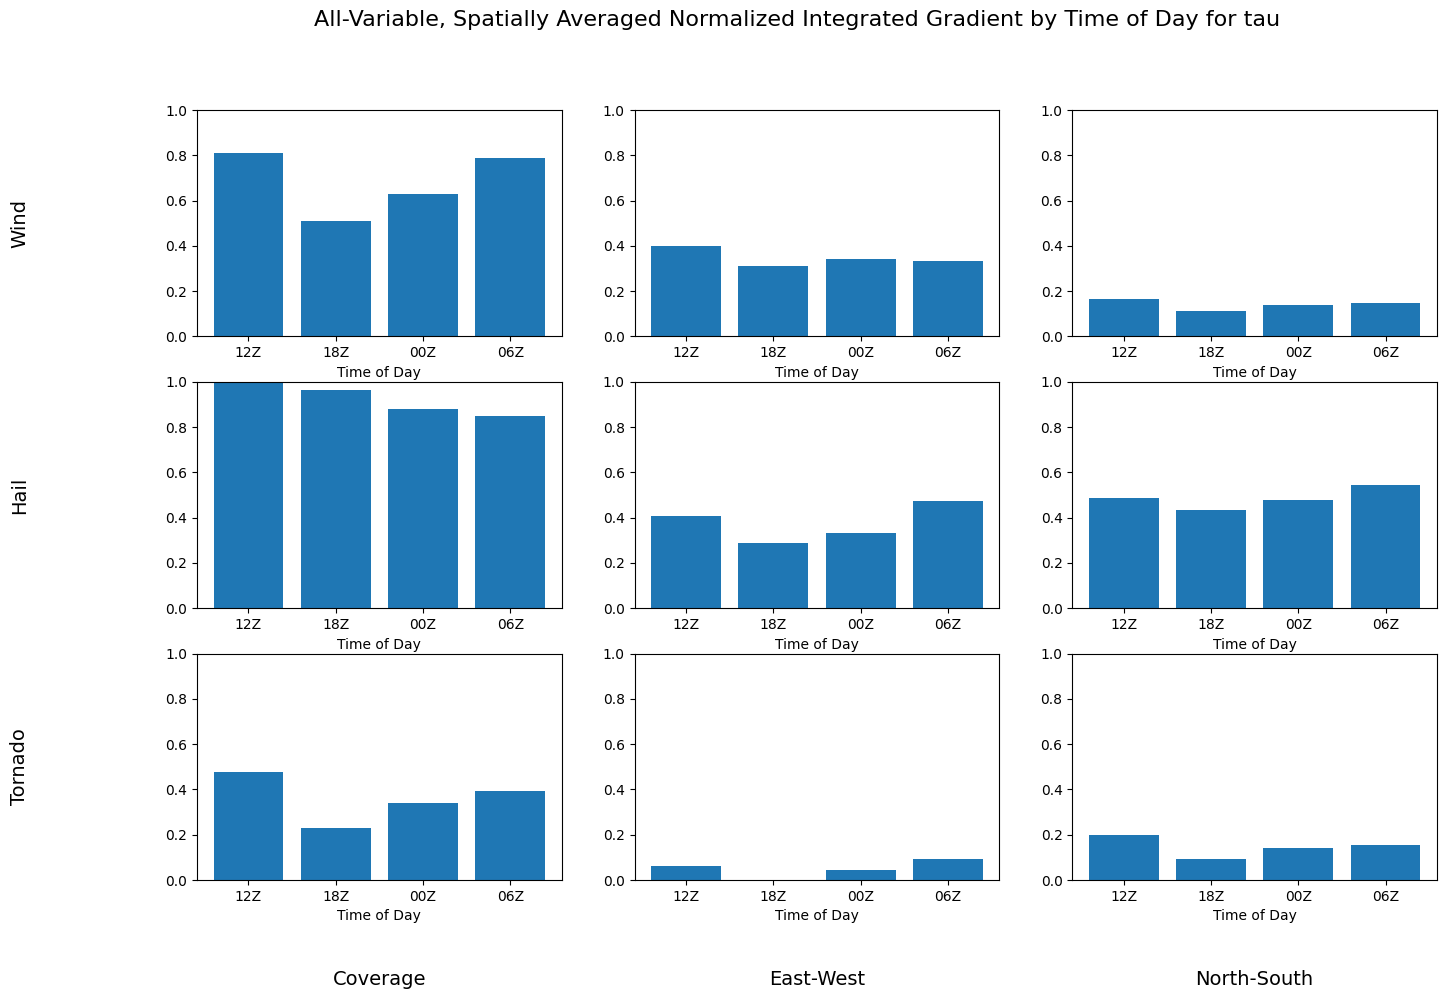

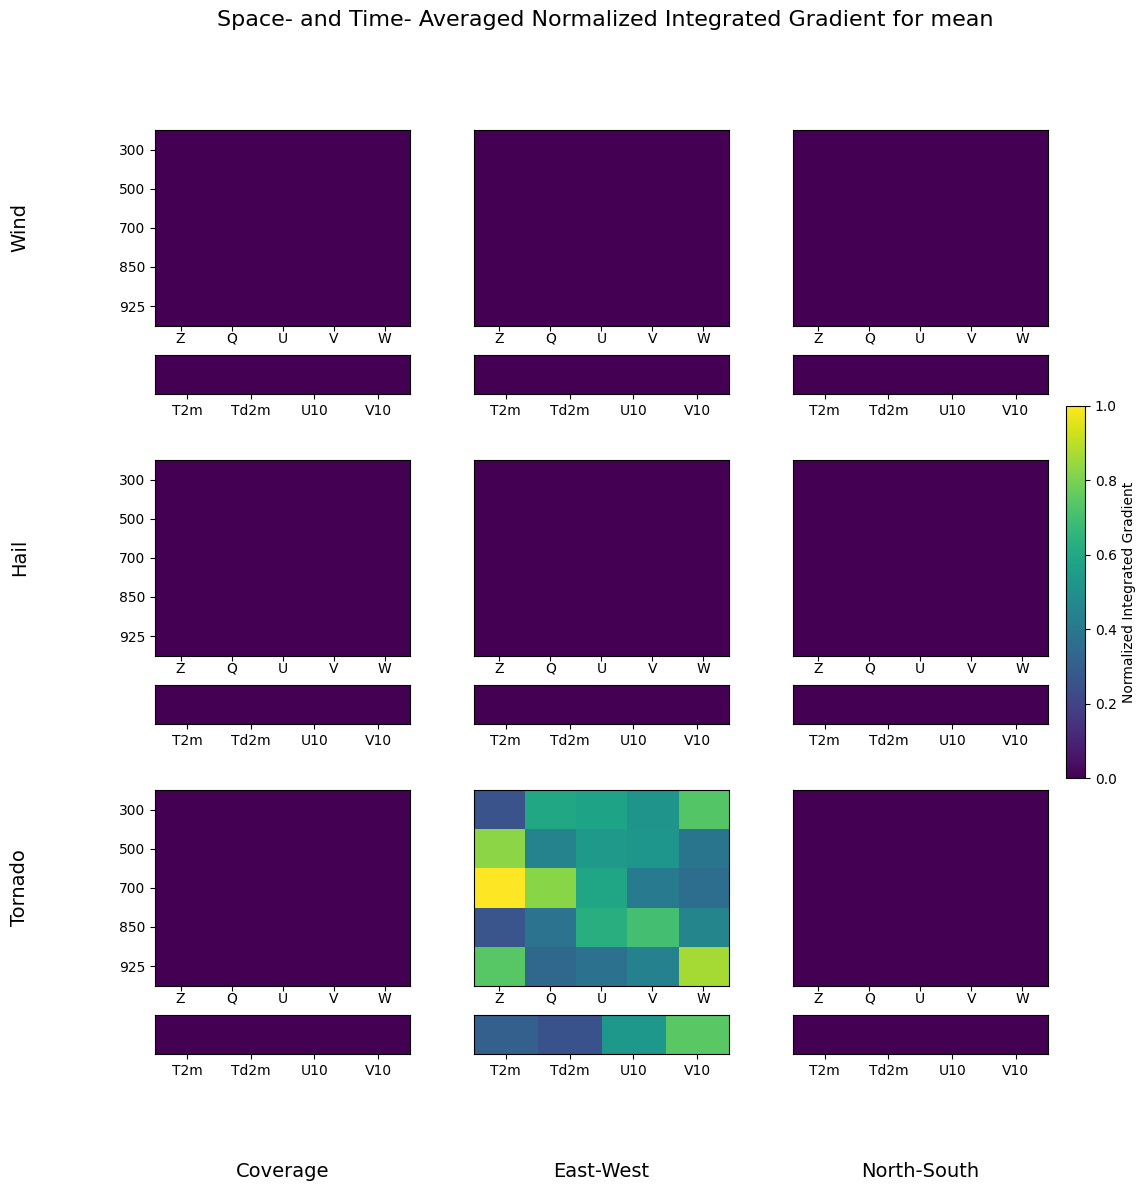

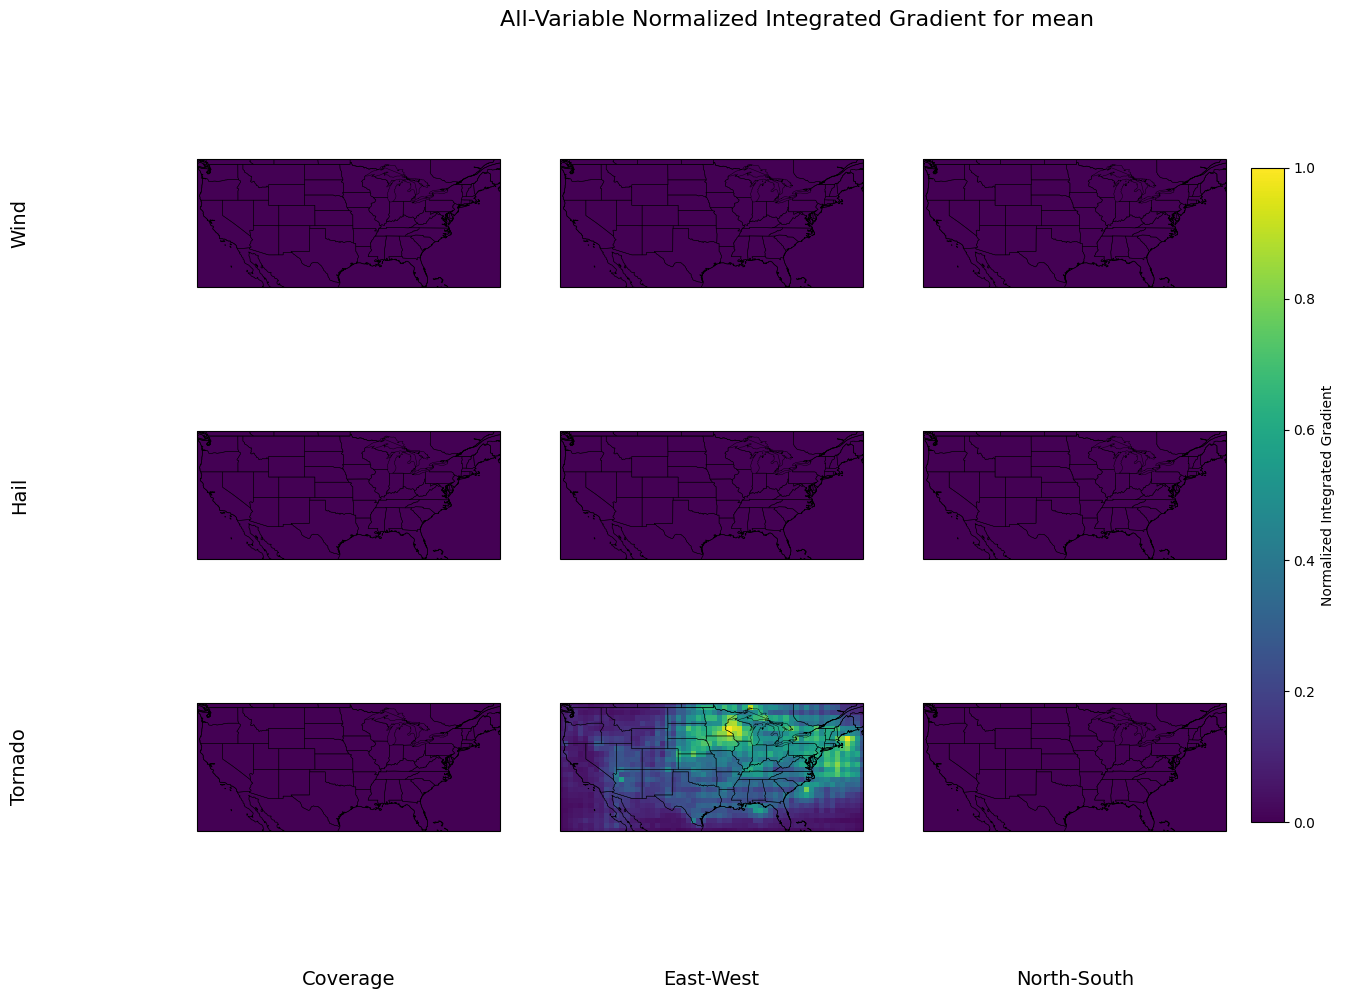

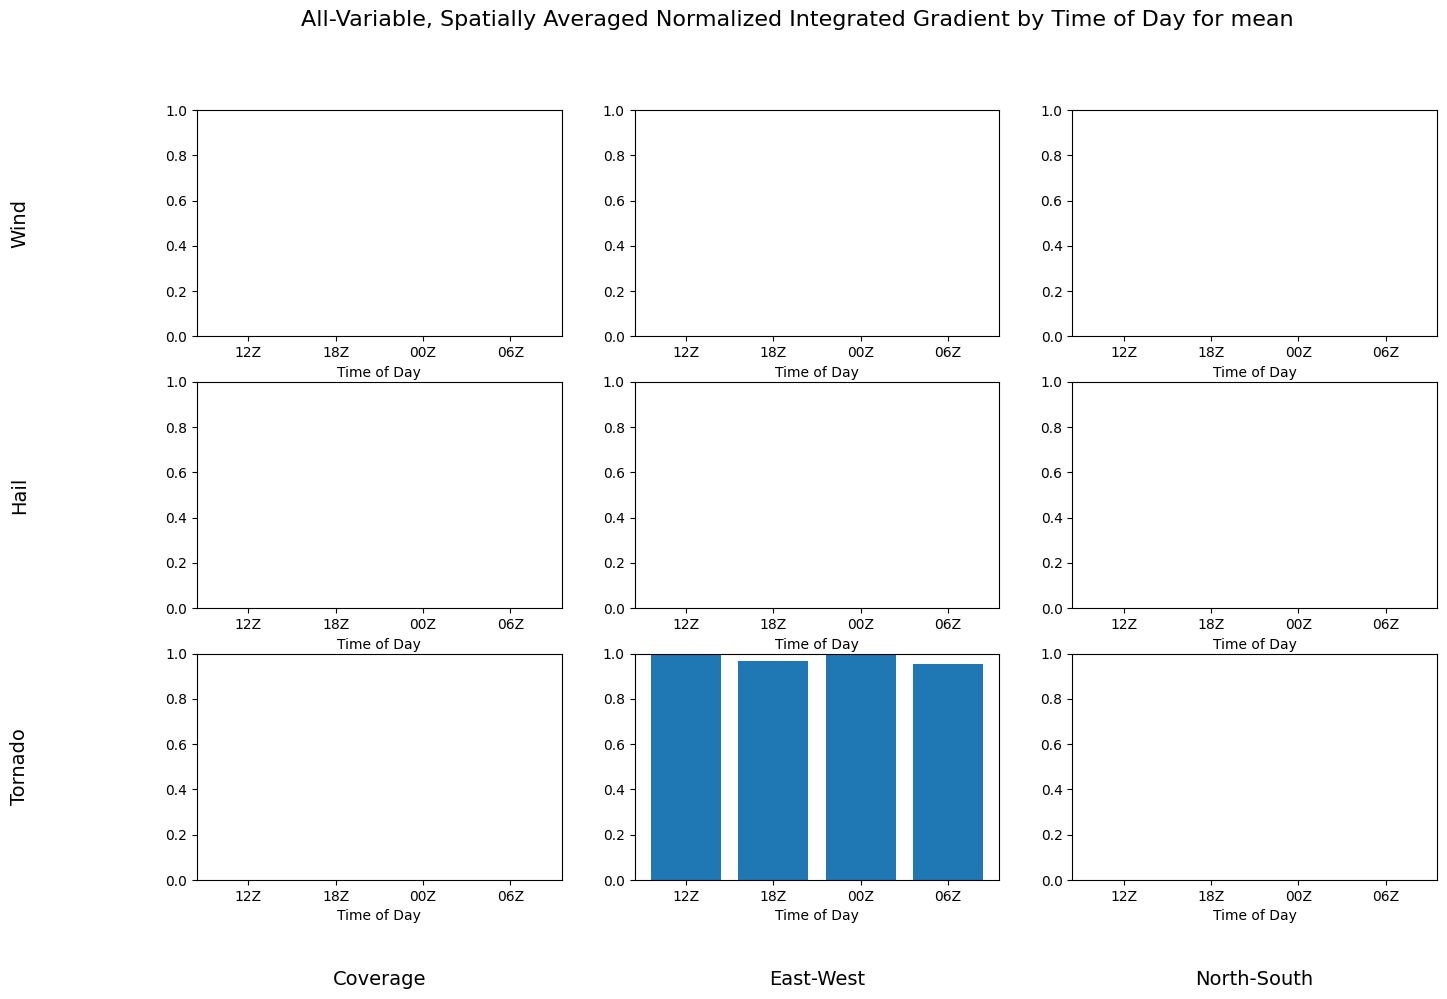

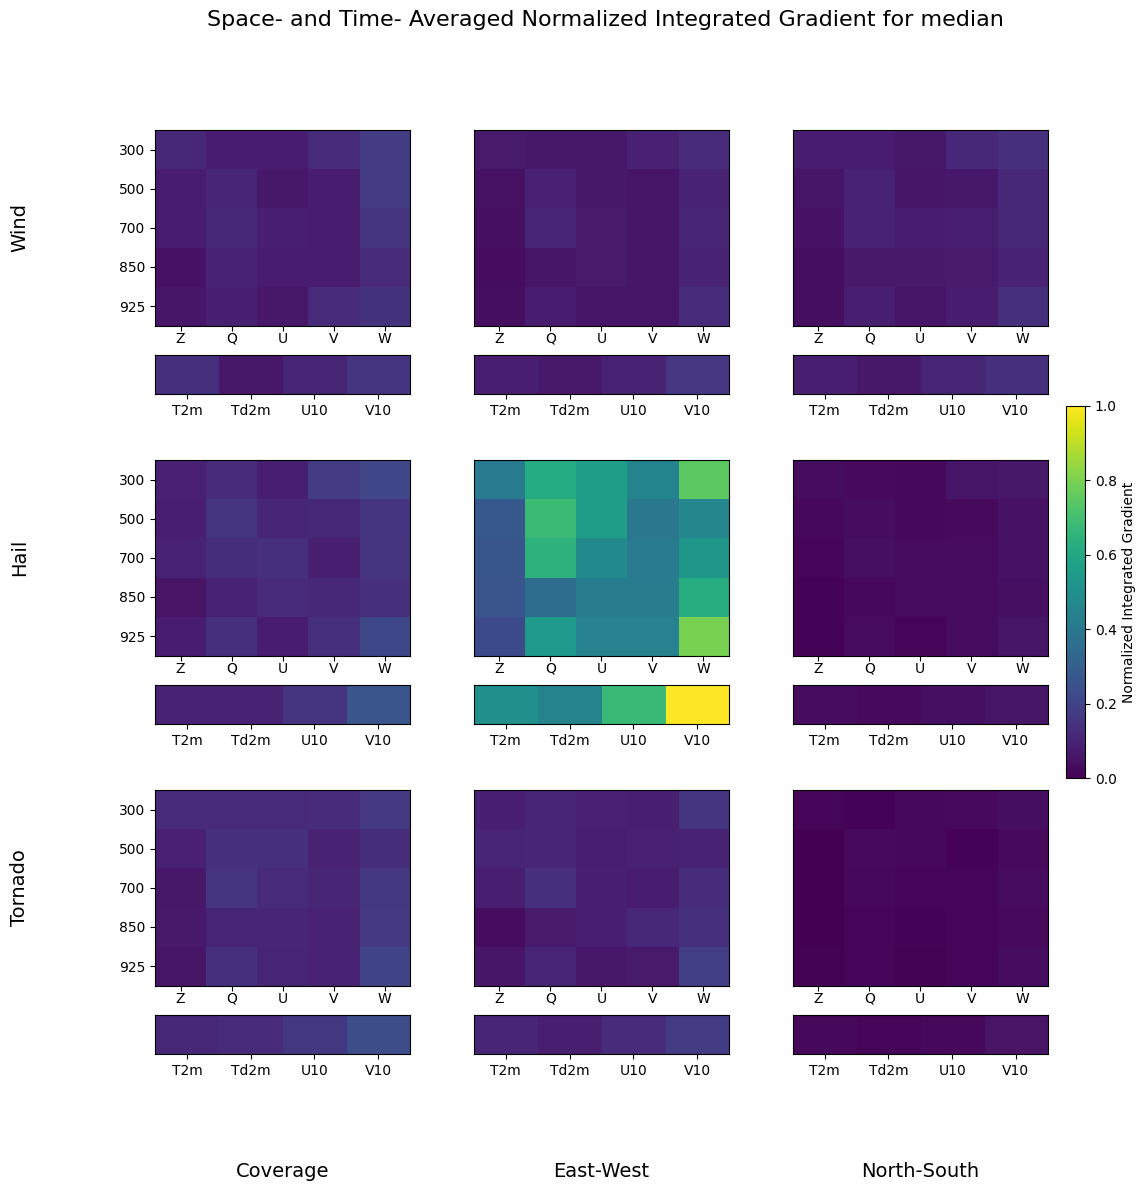

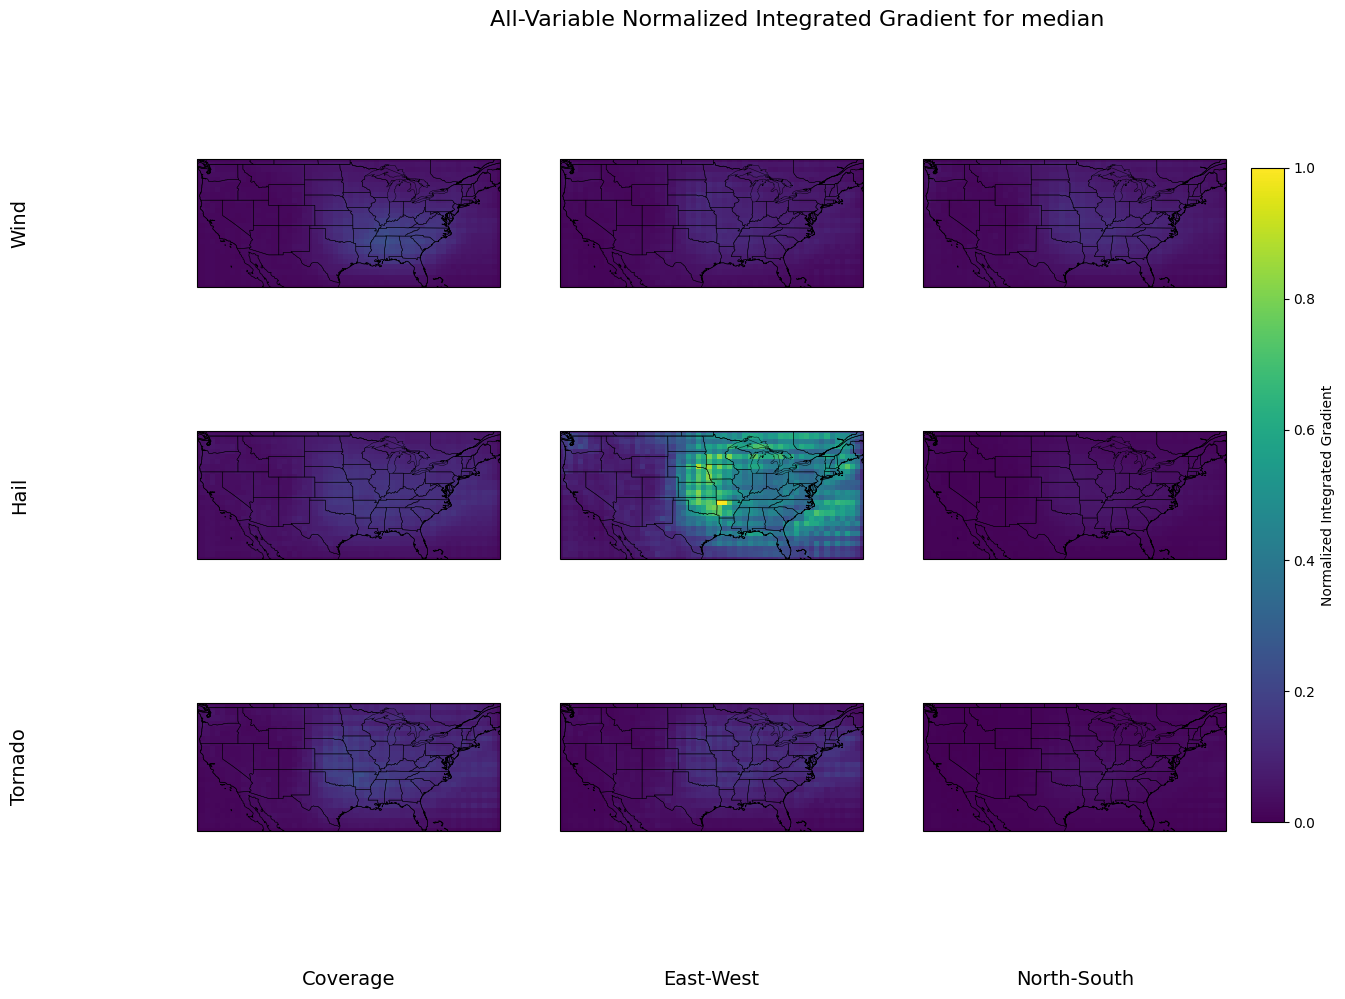

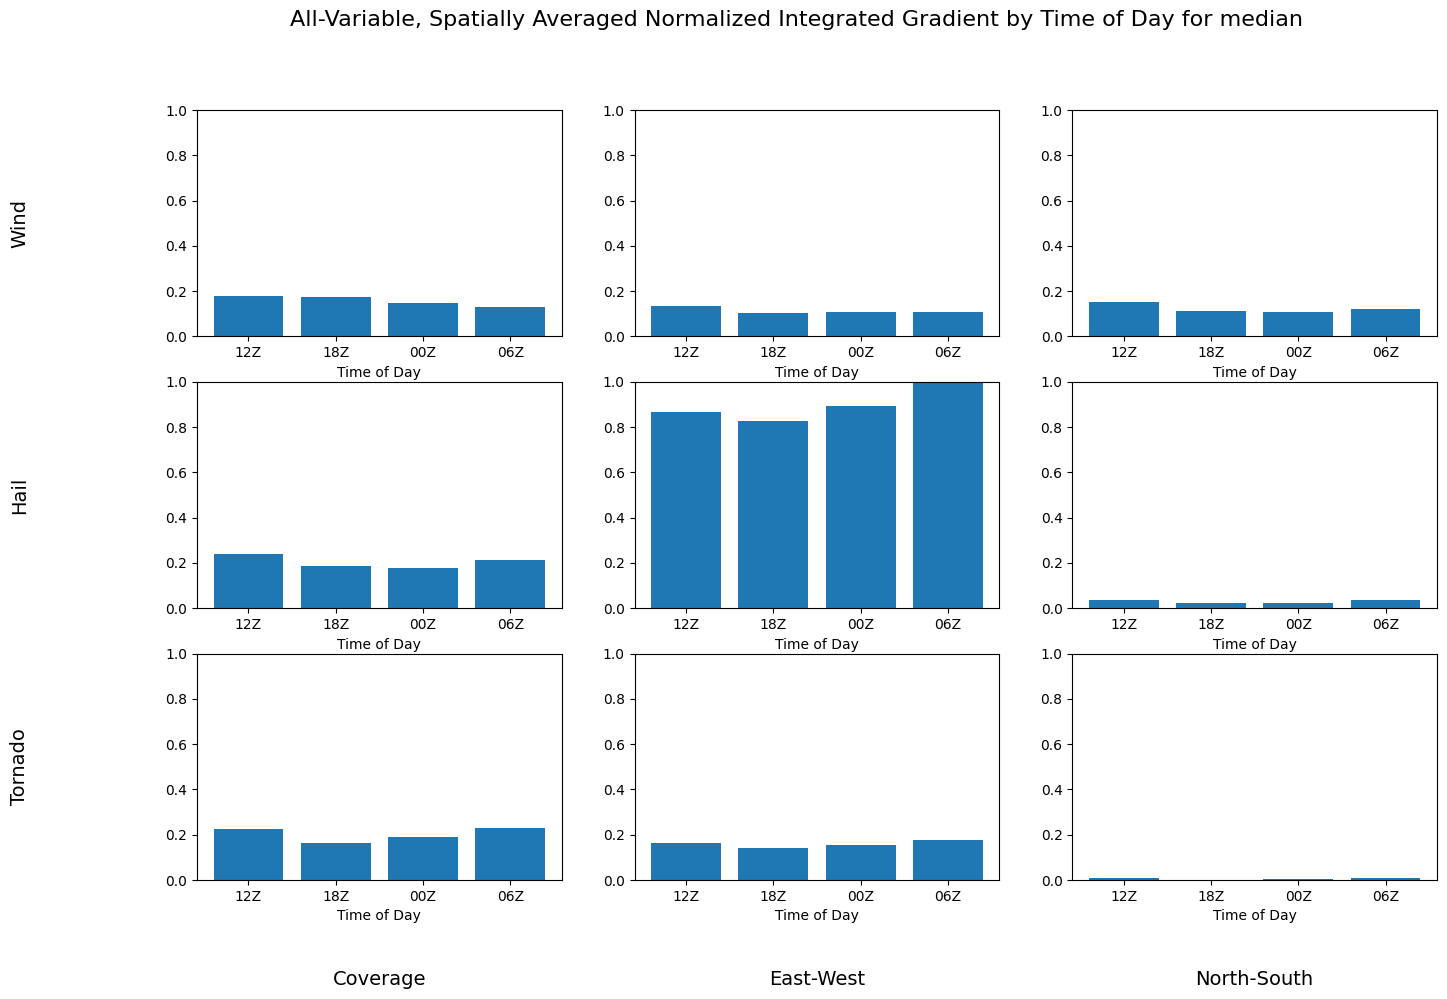

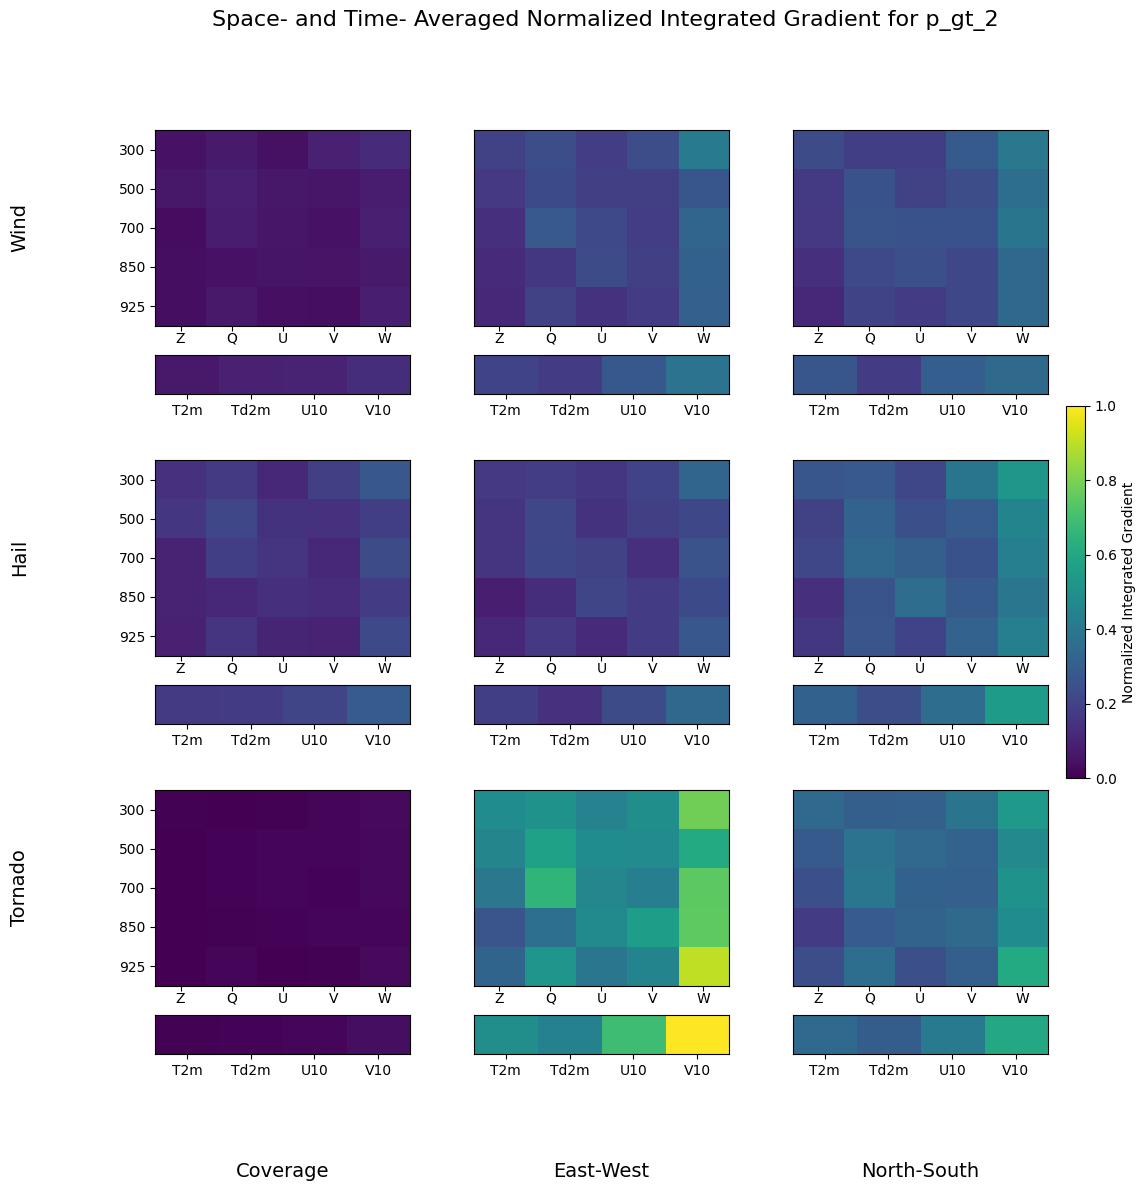

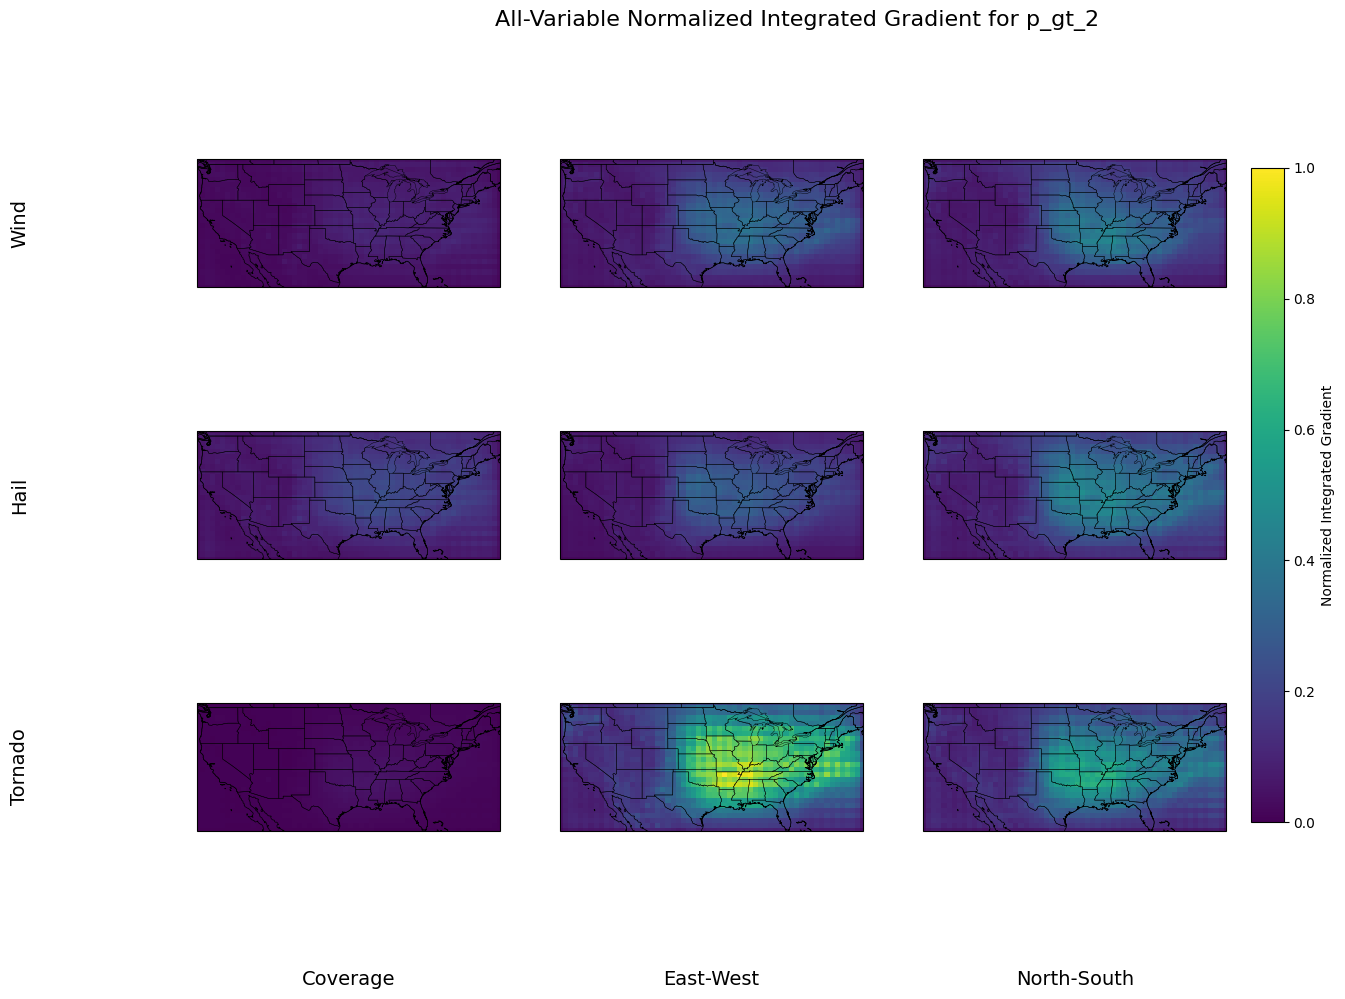

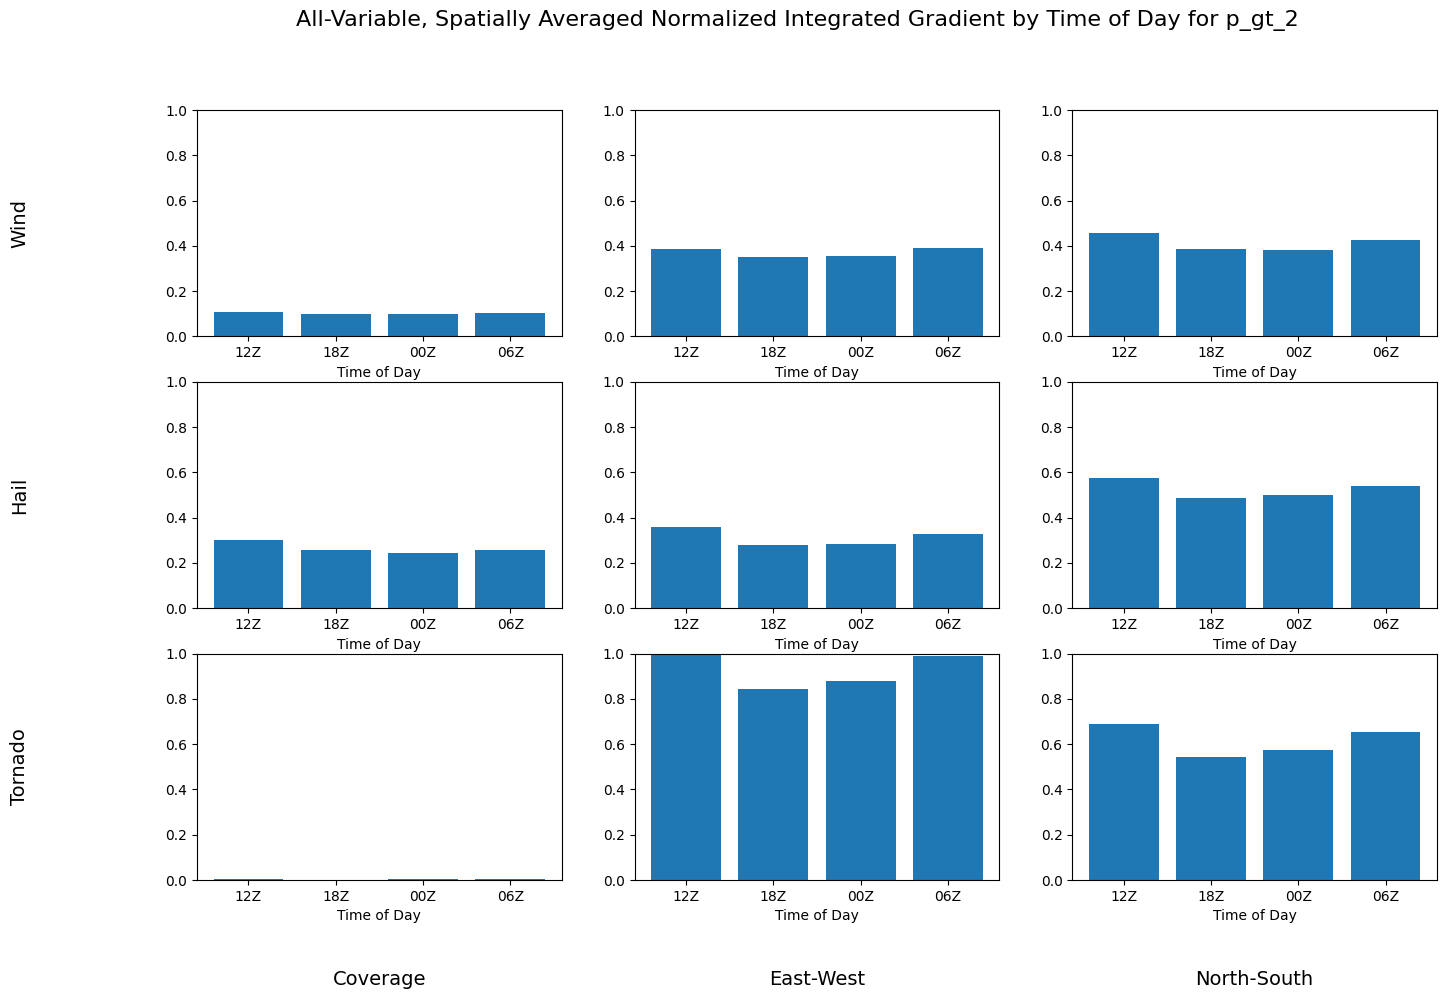

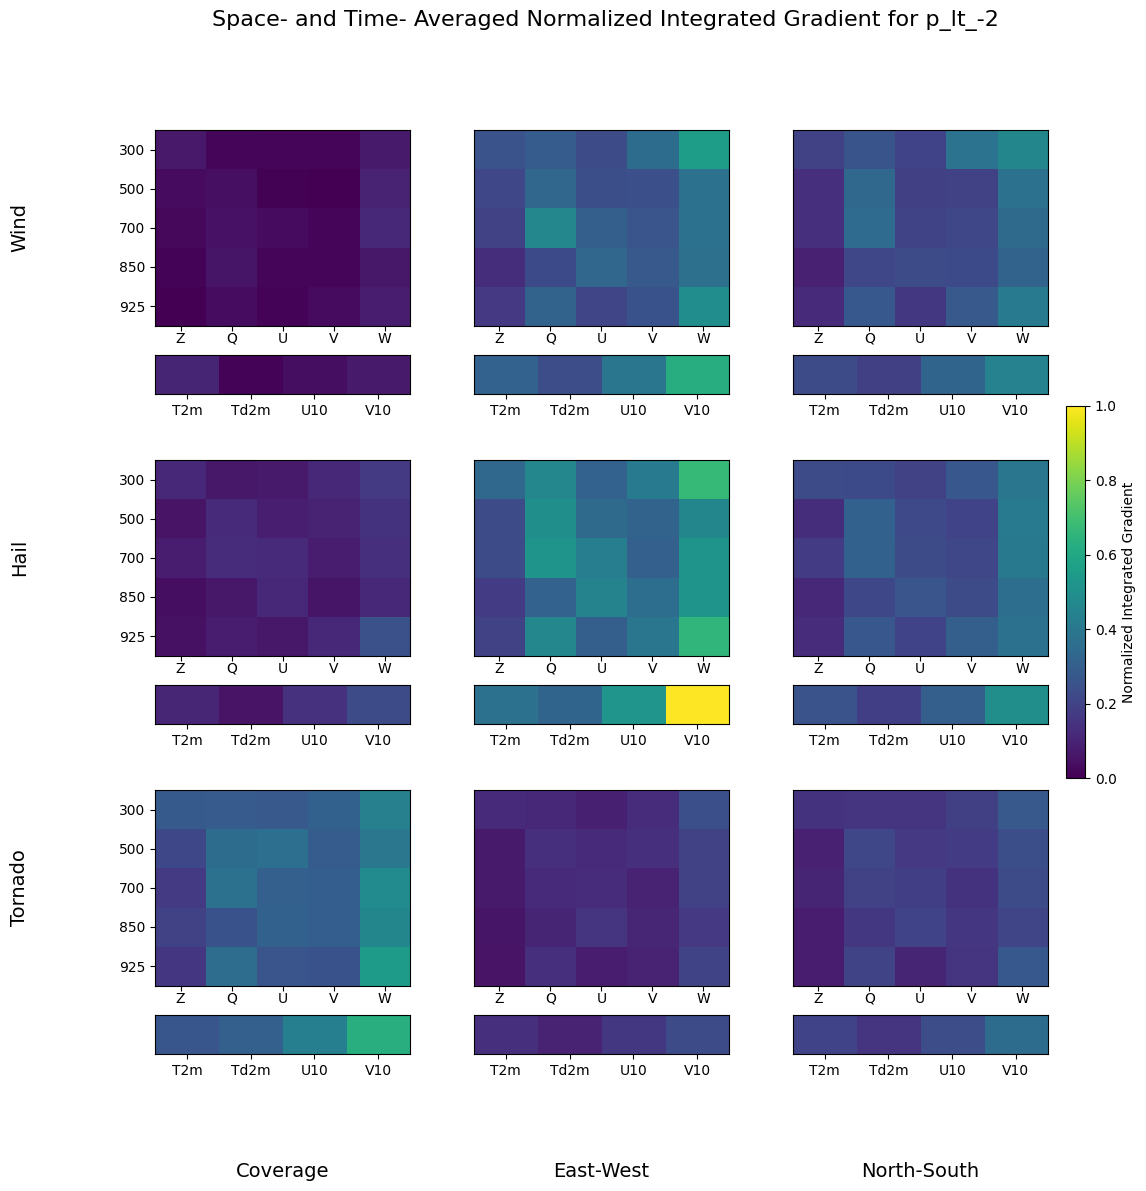

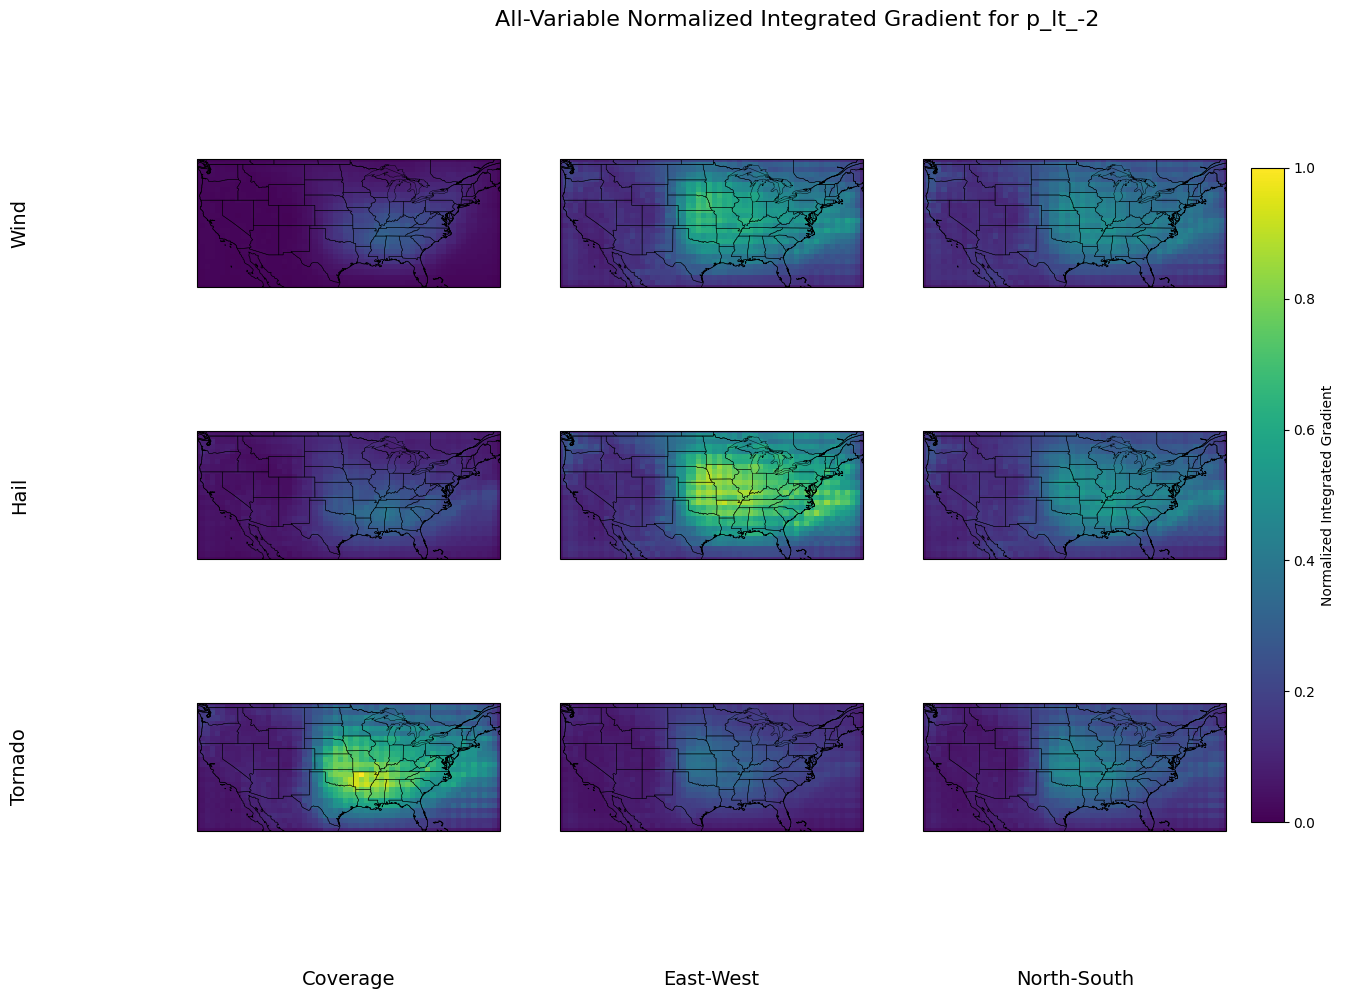

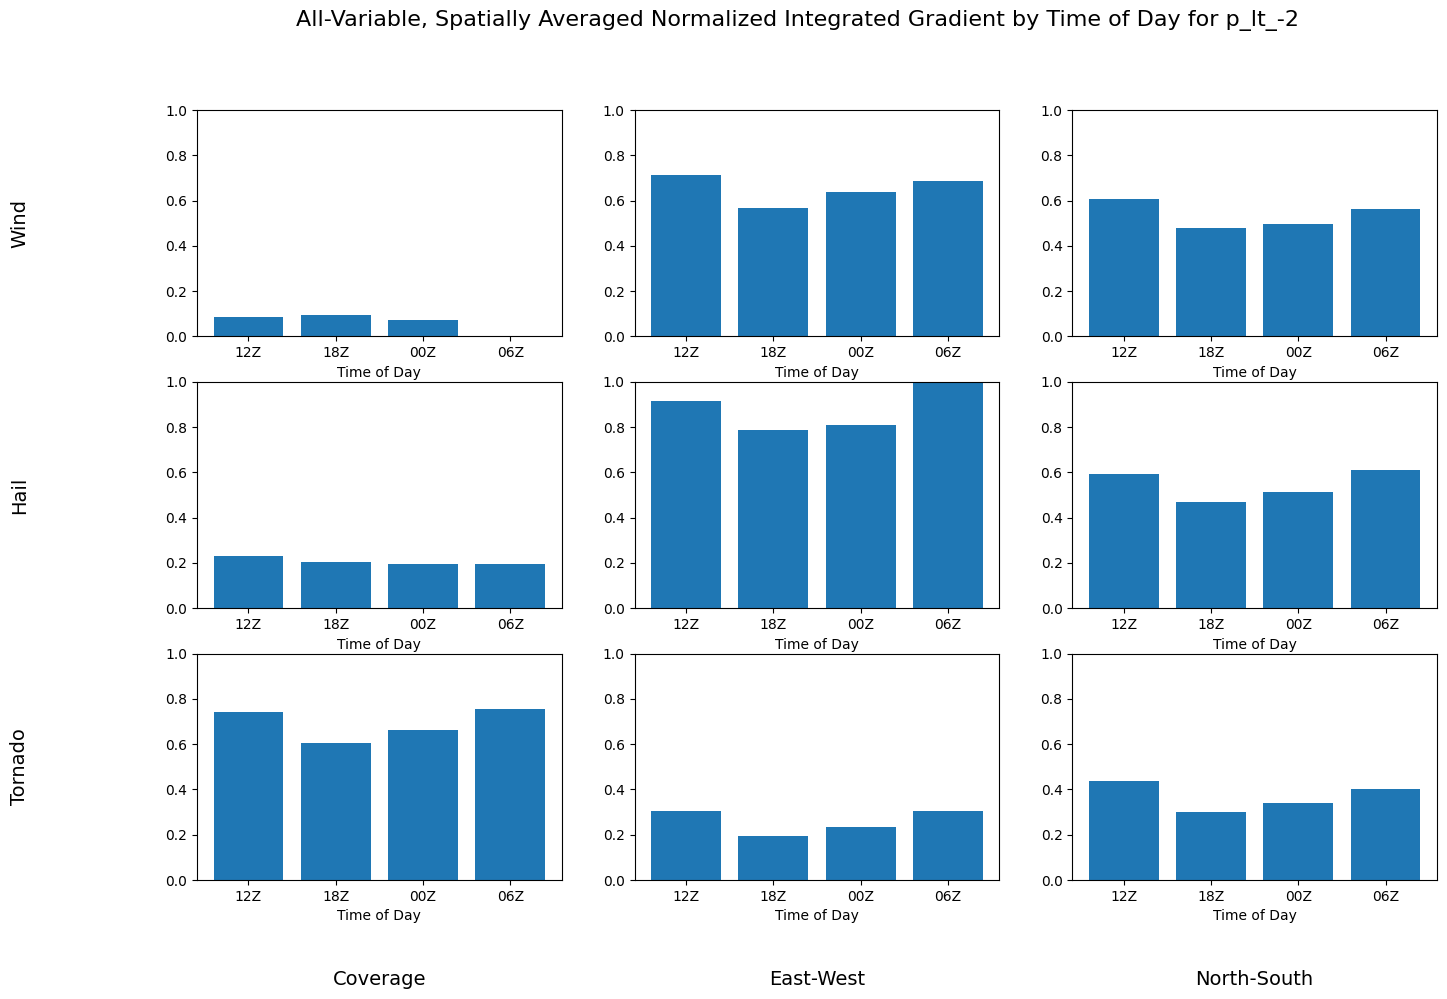

In [10]:
lats = np.arange(50, 24, -1)      # 50 down to 25
lons = np.arange(-125, -65, 1)    # -125 to -66

def split_tensor(x):
    z = x[4:9]
    q = x[9:14]
    u = x[14:19]
    v = x[19:24]
    w = x[24:29]
    heat_5x5 = np.stack([z, q, u, v, w], axis=1)

    heat_1x4 = np.array([x[3], x[2], x[0], x[1]])[None, :]
    return heat_5x5, heat_1x4

row_labels = ["Wind", "Hail", "Tornado"]
col_labels = ["Coverage", "East-West", "North-South"]


for target in scalars:
    a = avg[target]
    channel_avgs = a['channel']
    cmin = torch.min(channel_avgs)
    cmax = torch.max(channel_avgs)
    
    ############ CHANNEL AVERAGED

    channel_avgs = (channel_avgs - cmin) / (cmax - cmin)

    fig = plt.figure(figsize=(12, 12))
    outer = fig.add_gridspec(3, 3, wspace=0.25, hspace=0.25)

    vmin, vmax = 0, 1
    im_for_cbar = None

    top_axes = [[None]*3 for _ in range(3)]

    for i in range(9):
        r, c = divmod(i, 3)
        inner = outer[r, c].subgridspec(2, 1, height_ratios=[5, 1], hspace=0.25)

        ax_top = fig.add_subplot(inner[0])
        ax_bot = fig.add_subplot(inner[1])

        h5, h1 = split_tensor(channel_avgs[i])
        top_axes[r][c] = ax_top  # representative for this outer cell

        im = ax_top.imshow(h5, vmin=vmin, vmax=vmax, aspect='auto', origin= 'lower')
        ax_bot.imshow(h1, vmin=vmin, vmax=vmax, aspect='auto')

        if im_for_cbar is None:
            im_for_cbar = im

        # --- X labels BETWEEN heatmaps ---
        
        ax_top.set_xticks(range(5))
        ax_top.set_xticklabels(['Z', 'Q', 'U', 'V', 'W'])
        ax_top.xaxis.set_ticks_position('bottom')
        ax_top.tick_params(axis='x', pad=1)  # push into the gap

        # --- Y labels ---
        if c == 0:
            ax_top.set_yticks(range(5))
            ax_top.set_yticklabels([925, 850, 700, 500, 300])
        else:
            ax_top.set_yticks([])

        # --- bottom 1x4 ---
        ax_bot.set_xticks(range(4))
        ax_bot.set_xticklabels(['T2m', 'Td2m', 'U10', 'V10'])
        ax_bot.set_yticks([])


    # single colorbar
    cbar = fig.colorbar(im_for_cbar, ax=fig.axes, fraction=0.02, pad=0.02)
    cbar.set_label('Normalized Integrated Gradient')
    
    # Row labels (left)
    for r, label in enumerate(row_labels):
        pos = top_axes[r][0].get_position()
        y = (pos.y0 + pos.y1) / 2
        fig.text(0.02, y, label, va='center', ha='right', rotation=90, fontsize=14)

    # Column labels (bottom)
    for c, label in enumerate(col_labels):
        pos = top_axes[2][c].get_position()
        x = (pos.x0 + pos.x1) / 2
        fig.text(x, 0.02, label, va='top', ha='center', fontsize=14)

    fig.suptitle(f'Space- and Time- Averaged Normalized Integrated Gradient for {target}', fontsize=16)
    plt.savefig(f"figs/integrated_gradients/{target}/channel_avg.pdf", bbox_inches = 'tight')
    plt.show()
    
    ############### SPATIALLY AVERAGED

    spatial_avgs = a['spatial']
    
    # global color scale across all panels
    smin = torch.min(spatial_avgs)
    smax = torch.max(spatial_avgs)
    spatial_avgs = (spatial_avgs - smin) / (smax - smin)

    # 3x3 layout for 9 panels
    fig, axes = plt.subplots(
        3, 3,
        figsize=(16, 10),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    axes = axes.flatten()

    for i, ax in enumerate(axes):

        data = spatial_avgs[i]

        ax.set_extent([-125, -66, 25, 50], crs = ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)

        mesh = ax.pcolormesh(
            lons,
            lats,
            data,
            cmap='viridis',
            shading='auto',
            vmin=0,
            vmax=1,
            transform=ccrs.PlateCarree()
        )

    # single shared colorbar
    cbar = fig.colorbar(
        mesh,
        ax=axes,
        orientation='vertical',
        shrink=0.85,
        pad=0.02
    )

    cbar.set_label("Normalized Integrated Gradient")

    axes2d = axes.reshape(3, 3)
    # --- Row labels (left side) ---
    for i, label in enumerate(row_labels):
        # y position = center of each row of axes
        y = (axes2d[i, 0].get_position().y0 + axes2d[i, 0].get_position().y1) / 2
        fig.text(
            0.02, y, label,
            va='center', ha='right',
            rotation=90,
            fontsize=14
        )

    # --- Column labels (bottom) ---
    for j, label in enumerate(col_labels):
        # x position = center of each column of axes
        x = (axes2d[2, j].get_position().x0 + axes2d[2, j].get_position().x1) / 2
        fig.text(
            x, 0.02, label,
            va='top', ha='center',
            fontsize=14
        )

    fig.suptitle(f'All-Variable Normalized Integrated Gradient for {target}', fontsize=16)
    plt.savefig(f"figs/integrated_gradients/{target}/space_avg.pdf", bbox_inches = 'tight')
    plt.show()

    ############## TEMPORALLY AVERAGED

    temporal_avgs = a['temporal']

    # global color scale across all panels
    tmin = torch.min(temporal_avgs)
    tmax = torch.max(temporal_avgs)
    temporal_avgs = (temporal_avgs - tmin) / (tmax - tmin)

    # 3x3 layout for 9 panels
    fig, axes = plt.subplots(
        3, 3,
        figsize=(16, 10)
    )
    axes = axes.flatten()

    for i, ax in enumerate(axes):

        data = temporal_avgs[i]
        im = ax.bar(x = ['12Z', '18Z', '00Z', '06Z'], height = data)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Time of Day')
    fig.suptitle(f'All-Variable, Spatially Averaged Normalized Integrated Gradient by Time of Day for {target}', fontsize=16)

    axes2d = axes.reshape(3, 3)
    # --- Row labels (left side) ---
    for i, label in enumerate(row_labels):
        # y position = center of each row of axes
        y = (axes2d[i, 0].get_position().y0 + axes2d[i, 0].get_position().y1) / 2
        fig.text(
            0.02, y, label,
            va='center', ha='right',
            rotation=90,
            fontsize=14
        )

    # --- Column labels (bottom) ---
    for j, label in enumerate(col_labels):
        # x position = center of each column of axes
        x = (axes2d[2, j].get_position().x0 + axes2d[2, j].get_position().x1) / 2
        fig.text(
            x, 0.02, label,
            va='top', ha='center',
            fontsize=14
        )

    plt.savefig(f"figs/integrated_gradients/{target}/time_avg.pdf", bbox_inches = 'tight')
    plt.show()
    